# IF3170 Artificial Intelligence | Tugas Besar 2


Group Number: 12

Group Members:
- Surya Suharna (18223075)
- Muhammad Aymar Barkhaya (18223051)
- Ni Made Sekar Jelita Parameswari (18223101)
- Muhammad Azzam Robbani (18223025)


## Import Libraries

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,  RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
import warnings
import missingno as msno
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE

warnings.filterwarnings('ignore')
import pickle
import time

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


## Import Dataset

In [154]:
# Import dataset
import os

# Try to load data from data directory
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print("Train dataset shape:", train_df.shape)
print("Test dataset shape:", test_df.shape)
print("\n=== Data Overview ===")
print(f"Training samples: {len(train_df):,}")
print(f"Test samples: {len(test_df):,}")
print(f"Number of features: {train_df.shape[1] - 1}")
print(f"\nTarget distribution:")
print(train_df['is_fraud'].value_counts())
print(f"Fraud percentage: {train_df['is_fraud'].mean()*100:.2f}%")

Train dataset shape: (100000, 31)
Test dataset shape: (100000, 30)

=== Data Overview ===
Training samples: 100,000
Test samples: 100,000
Number of features: 30

Target distribution:
is_fraud
0    85872
1    14128
Name: count, dtype: int64
Fraud percentage: 14.13%


In [155]:
# Display basic information
print("=== Training Data Info ===")
print(train_df.info())
print("\n=== Training Data Description ===")
print(train_df.describe())
print("\n=== Missing Values ===")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])

=== Training Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ID                      100000 non-null  int64  
 1   transaction_id          100000 non-null  object 
 2   user_id                 100000 non-null  int64  
 3   age                     100000 non-null  int64  
 4   gender                  100000 non-null  object 
 5   country                 100000 non-null  object 
 6   device_type             100000 non-null  object 
 7   device_os               100000 non-null  object 
 8   merchant_category       100000 non-null  object 
 9   transaction_amount      97581 non-null   float64
 10  transaction_type        100000 non-null  object 
 11  time_of_day             100000 non-null  int64  
 12  day_of_week             100000 non-null  int64  
 13  transaction_duration    100000 non-null  float64

# Exploratory Data Analysis (Optional)

Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that involves examining and visualizing data sets to uncover patterns, trends, anomalies, and insights. It is the first step before applying more advanced statistical and machine learning techniques. EDA helps you to gain a deep understanding of the data you are working with, allowing you to make informed decisions and formulate hypotheses for further analysis.

## Inspecting Data

In [156]:
# Check Data Size
print(f"Jumlah baris: {train_df.shape[0]}, Jumlah kolom: {train_df.shape[1]}")

Jumlah baris: 100000, Jumlah kolom: 31


In [157]:
# Identify Data Types
print(train_df.dtypes)

ID                          int64
transaction_id             object
user_id                     int64
age                         int64
gender                     object
country                    object
device_type                object
device_os                  object
merchant_category          object
transaction_amount        float64
transaction_type           object
time_of_day                 int64
day_of_week                 int64
transaction_duration      float64
num_prev_transactions       int64
avg_transaction_amount    float64
std_transaction_amount    float64
transactions_last_24h       int64
transactions_last_1h        int64
failed_login_attempts       int64
ip_risk_score             float64
device_trust_score        float64
account_age_days            int64
has_chargeback_history      int64
shared_ip_users             int64
shared_device_users         int64
merchant_risk             float64
country_risk              float64
distance_from_home        float64
is_new_country


Features with missing values:
['transaction_amount', 'avg_transaction_amount', 'device_trust_score']

Total count of missing values in the dataset:
7257

Total Count of missing values per feature:
ID                           0
transaction_id               0
user_id                      0
age                          0
gender                       0
country                      0
device_type                  0
device_os                    0
merchant_category            0
transaction_amount        2419
transaction_type             0
time_of_day                  0
day_of_week                  0
transaction_duration         0
num_prev_transactions        0
avg_transaction_amount    2419
std_transaction_amount       0
transactions_last_24h        0
transactions_last_1h         0
failed_login_attempts        0
ip_risk_score                0
device_trust_score        2419
account_age_days             0
has_chargeback_history       0
shared_ip_users              0
shared_device_users        

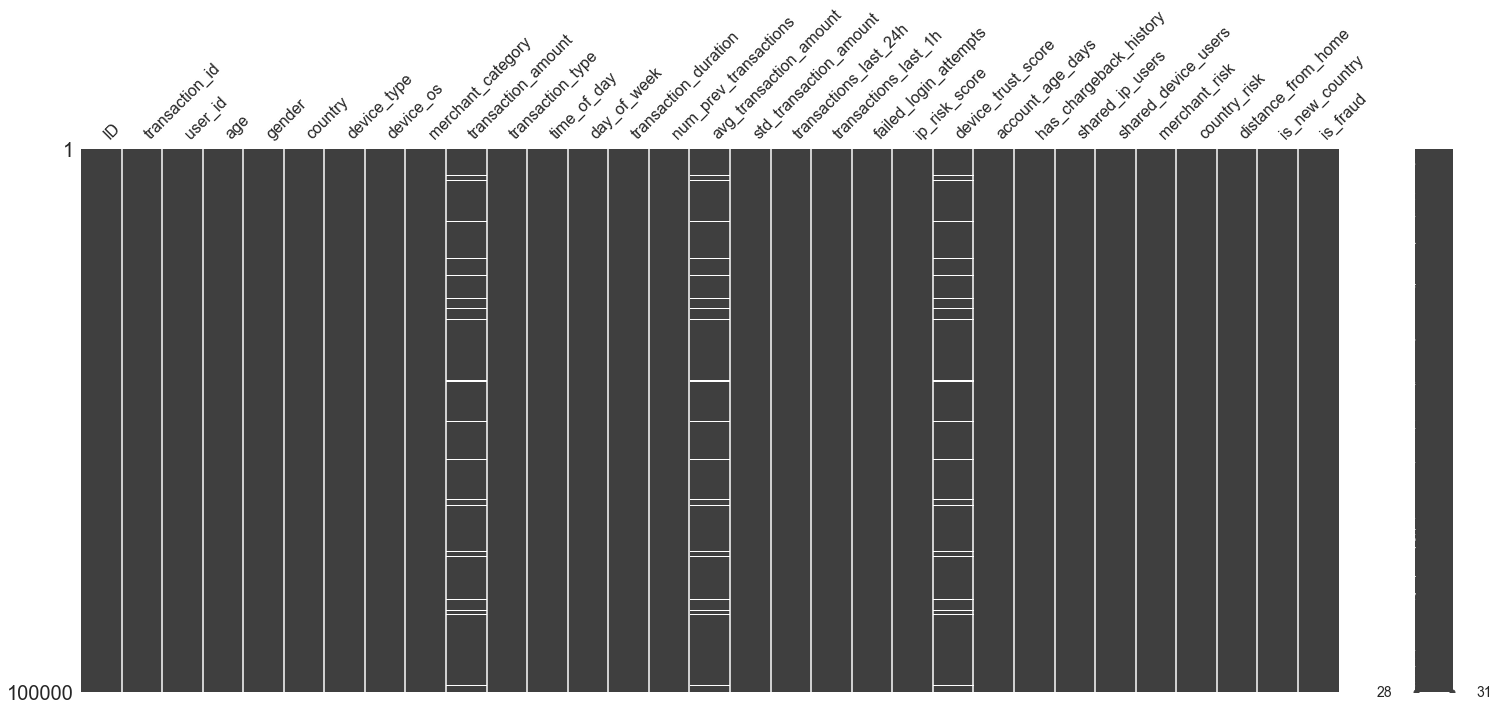

In [158]:
# Which feature has missing values?
print("\nFeatures with missing values:")
print([col for col in train_df.columns if train_df[col].isnull().any()])

print("\nTotal count of missing values in the dataset:")
print(train_df.isnull().values.sum())

print("\nTotal Count of missing values per feature:")
print(train_df.isna().sum())

# Visualize missing values
msno.matrix(train_df)
plt.show()

In [159]:
# Display basic information
print("=== Training Data Info ===")
print(train_df.info())


=== Training Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ID                      100000 non-null  int64  
 1   transaction_id          100000 non-null  object 
 2   user_id                 100000 non-null  int64  
 3   age                     100000 non-null  int64  
 4   gender                  100000 non-null  object 
 5   country                 100000 non-null  object 
 6   device_type             100000 non-null  object 
 7   device_os               100000 non-null  object 
 8   merchant_category       100000 non-null  object 
 9   transaction_amount      97581 non-null   float64
 10  transaction_type        100000 non-null  object 
 11  time_of_day             100000 non-null  int64  
 12  day_of_week             100000 non-null  int64  
 13  transaction_duration    100000 non-null  float64

In [160]:
# Unique Values in Categorical Features

#Transaction Type
print("Transaction Type Description and Unique Values:")
transaction_type_desc = train_df["transaction_type"].describe()
unique_transtype = train_df['transaction_type'].unique()

print(transaction_type_desc)
print(unique_transtype)

# Device OS
print("\nDevice OS Description and Unique Values:")
deviceos_desc = train_df["device_os"].describe()
unique_deviceos = train_df['device_os'].unique()

print(deviceos_desc)
print(unique_deviceos)

# Device Type
print("\nDevice Type Description and Unique Values:")
devicetype_desc = train_df["device_type"].describe()
unique_devicetype = train_df['device_type'].unique()

print(devicetype_desc)
print(unique_devicetype)

Transaction Type Description and Unique Values:
count       100000
unique           4
top       purchase
freq         59395
Name: transaction_type, dtype: object
['purchase' 'topup' 'withdrawal' 'transfer']

Device OS Description and Unique Values:
count      100000
unique          5
top       Android
freq        49183
Name: device_os, dtype: object
['Android' 'iOS' 'Windows' 'Linux' 'MacOS']

Device Type Description and Unique Values:
count     100000
unique         3
top       mobile
freq       78292
Name: device_type, dtype: object
['mobile' 'desktop' 'tablet']


## Exploring Data Characteristics

In [161]:
print("=== Statistik Deskriptif untuk Data Numerik ===\n")
print(train_df.describe())

=== Statistik Deskriptif untuk Data Numerik ===

                  ID        user_id            age  transaction_amount  \
count  100000.000000  100000.000000  100000.000000        97581.000000   
mean    49999.500000   15040.173180      48.484150          126.855288   
std     28867.657797    8655.074007      17.892168          376.035544   
min         0.000000       1.000000      18.000000            0.010000   
25%     24999.750000    7549.000000      33.000000           26.910000   
50%     49999.500000   15093.000000      48.000000           64.460000   
75%     74999.250000   22541.000000      64.000000          131.060000   
max     99999.000000   29999.000000      79.000000        20601.133350   

         time_of_day    day_of_week  transaction_duration  \
count  100000.000000  100000.000000         100000.000000   
mean       12.770160       2.780700              3.999587   
std         5.748626       2.064754              4.012831   
min         0.000000       0.000000     

## Eksplorasi Data

In [162]:
train_df["country"].value_counts()

country
US    29731
IN    29375
ID    12064
CA    11221
UK    10835
BR     2601
FR     1766
DE     1462
SG      495
AU      450
Name: count, dtype: int64

In [163]:
# Summary Statistics of Numerical Features including Skewness and Kurtosis
summary = pd.DataFrame()

summary["min"] = train_df.min(numeric_only=True)
summary["max"] = train_df.max(numeric_only=True)
summary["mean"] = train_df.mean(numeric_only=True)
summary["median"] = train_df.median(numeric_only=True)
summary["mode"] = train_df.mode(numeric_only=True).iloc[0]
summary["std"] = train_df.std(numeric_only=True)
summary["skewness"] = train_df.skew(numeric_only=True)
summary["kurtosis"] = train_df.kurtosis(numeric_only=True)


summary

,min,max,mean,median,mode,std,skewness,kurtosis
ID,0.00,99999.000000,49999.500000,49999.500,0.000,28867.657797,0.000000,-1.200000
user_id,1.00,29999.000000,15040.173180,15093.000,18896.000,8655.074007,-0.007491,-1.197771
age,18.00,79.000000,48.484150,48.000,40.000,17.892168,0.002919,-1.195800
transaction_amount,0.01,20601.133350,126.855288,64.460,0.190,376.035544,14.793343,330.302199
time_of_day,0.00,23.000000,12.770160,12.000,18.000,5.748626,-0.184745,-1.021863
day_of_week,0.00,6.000000,2.780700,3.000,0.000,2.064754,0.066893,-1.375726
transaction_duration,0.00,52.070000,3.999587,2.760,0.140,4.012831,2.021264,6.248908
num_prev_transactions,8.00,59.000000,29.992080,30.000,29.000,5.486210,0.179529,0.030904
avg_transaction_amount,-52.89,195.790000,69.969722,69.990,84.350,29.961530,-0.000764,-0.034694
std_transaction_amount,5.00,80.000000,42.541209,42.480,47.350,21.652791,-0.000783,-1.198752


## Visualizing Relationship of Data

### Categorical Data

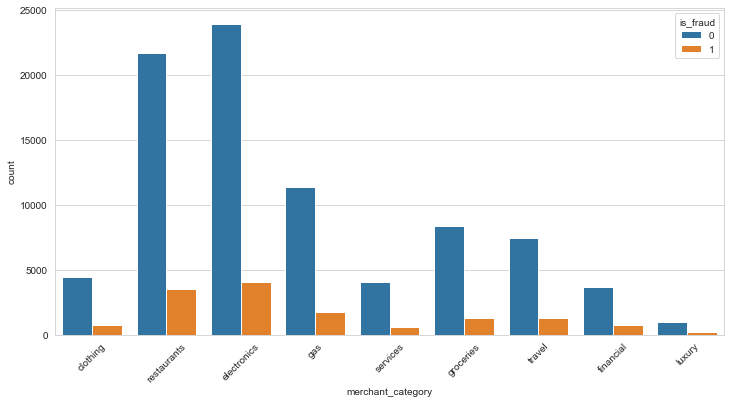

In [164]:
sns.countplot(data=train_df, x="merchant_category", hue="is_fraud")
plt.xticks(rotation=45)
plt.show()

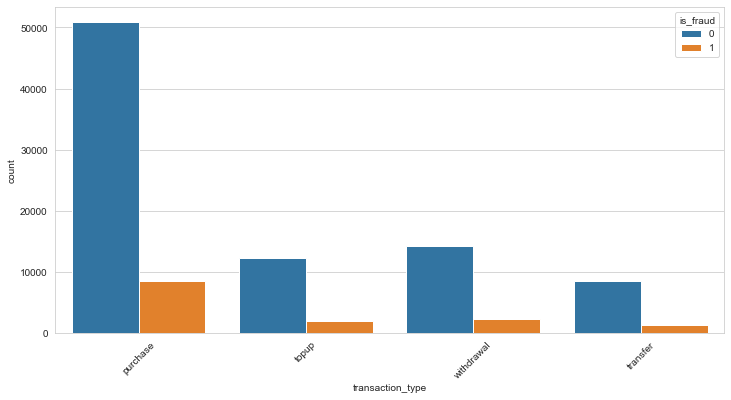

In [165]:
# Visualisasi Distribusi Kategori transaction_type
sns.countplot(data=train_df, x="transaction_type", hue="is_fraud")
plt.xticks(rotation=45)
plt.show()

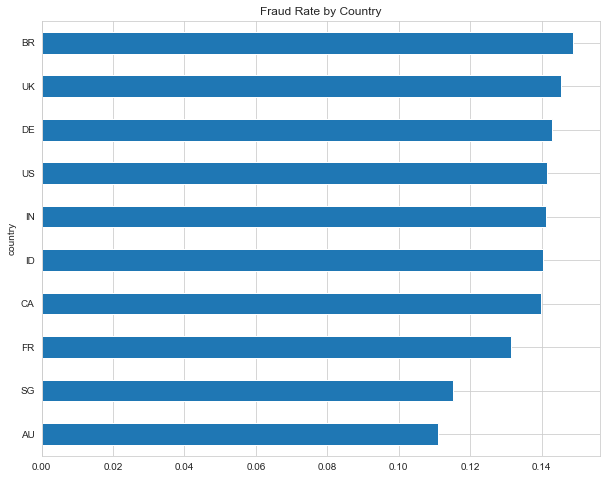

In [166]:
train_eda = train_df.copy()
(train_eda.groupby("country")["is_fraud"]
    .mean()
    .sort_values(ascending=True)
    .plot(kind="barh", figsize=(10,8)))
plt.title("Fraud Rate by Country")
plt.show()

In [167]:
bins = [0, 20, 30, 40, 50, 60, 70, 100]
labels = ["<20", "20-29", "30-39", "40-49", "50-59", "60-69", "70+"]

train_eda["age_group"] = pd.cut(train_eda["age"], bins=bins, labels=labels, right=False)


In [168]:
cat_cols = [col for col in train_df.columns 
            if train_df[col].dtype == 'object' or train_df[col].dtype.name == 'category']

#Unique values in categorical features
for col in cat_cols:
    print(col, train_df[col].nunique())

transaction_id 100000
gender 2
country 10
device_type 3
device_os 5
merchant_category 9
transaction_type 4


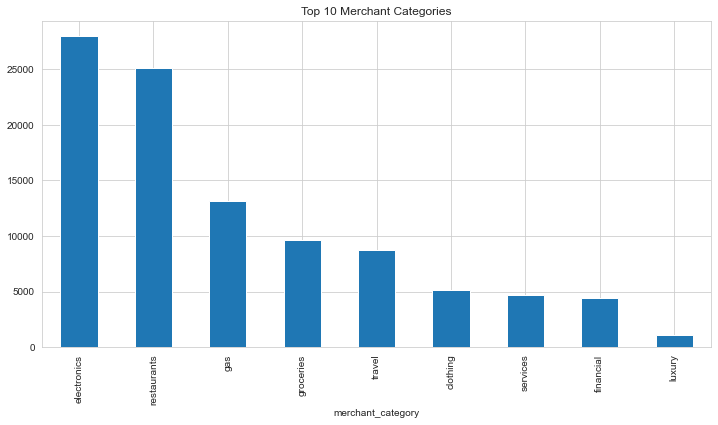

In [169]:
train_eda["merchant_category"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Merchant Categories")
plt.show()


### Numerical Data

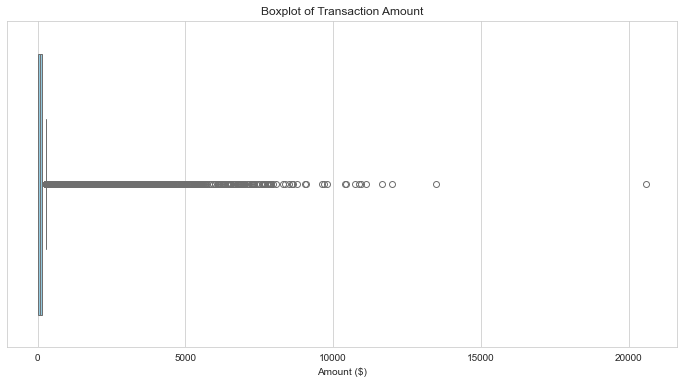

In [170]:
sns.boxplot(x=train_df['transaction_amount'], color='skyblue')

plt.title('Boxplot of Transaction Amount')
plt.xlabel('Amount ($)')
plt.show()

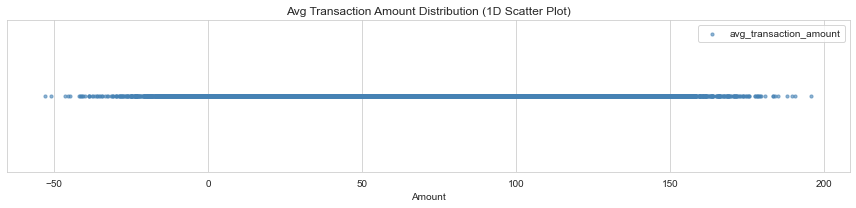

In [171]:
# 1D Scatter plot of avg_transaction_amount distribution
plt.figure(figsize=(12,3))
plt.scatter(train_df["avg_transaction_amount"], [0]*len(train_df), color="steelblue", alpha=0.6, s=10, label="avg_transaction_amount")
plt.title("Avg Transaction Amount Distribution (1D Scatter Plot)")
plt.xlabel("Amount")
plt.ylabel("")
plt.yticks([])  # Remove y-axis ticks since y=0 for all points
plt.legend()
plt.tight_layout()
plt.show()

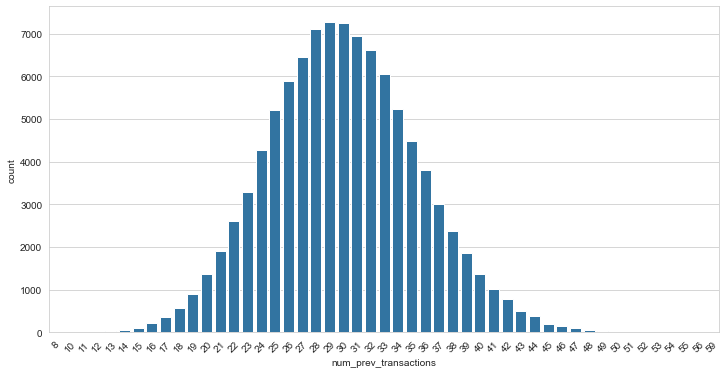

In [172]:
sns.countplot(data=train_df, x="num_prev_transactions")
plt.xticks(rotation=45)
plt.show()

### Relationship

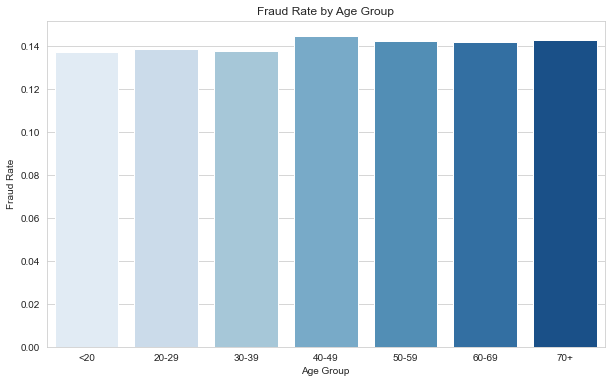

In [173]:
fraud_age = (
    train_eda.groupby("age_group")["is_fraud"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(data=fraud_age, x="age_group", y="is_fraud", palette="Blues")

plt.title("Fraud Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Fraud Rate")
plt.show()


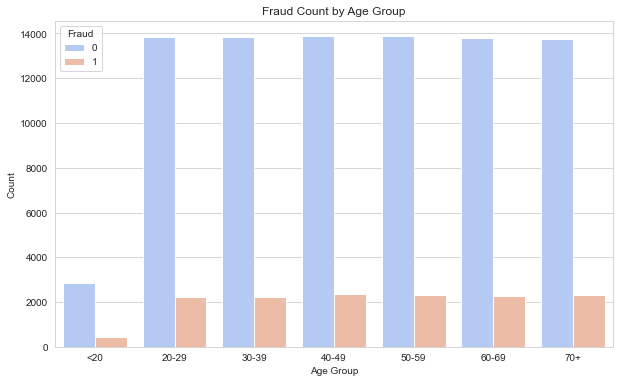

In [174]:
plt.figure(figsize=(10,6))
sns.countplot(data=train_eda, x="age_group", hue="is_fraud", palette="coolwarm")

plt.title("Fraud Count by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.legend(title="Fraud")
plt.show()


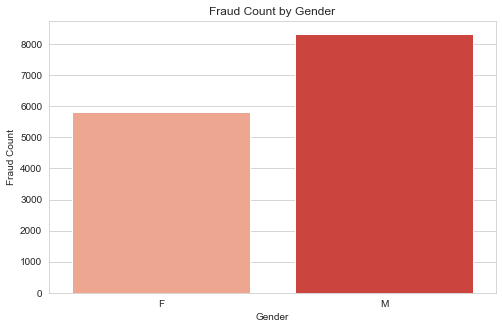

In [175]:
fraud_count_gender = (
    train_eda[train_eda["is_fraud"] == 1]
    .groupby("gender")
    .size()
    .reset_index(name="fraud_count")
)

plt.figure(figsize=(8,5))
sns.barplot(data=fraud_count_gender, x="gender", y="fraud_count", palette="Reds")

plt.title("Fraud Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Fraud Count")
plt.show()


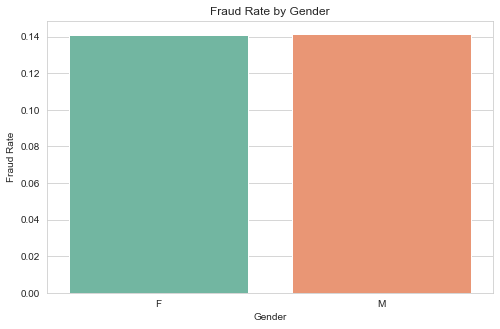

In [176]:
fraud_gender = (
    train_eda.groupby("gender")["is_fraud"]
      .mean()
      .reset_index()
      .rename(columns={"is_fraud": "fraud_rate"})
)

plt.figure(figsize=(8,5))
sns.barplot(data=fraud_gender, x="gender", y="fraud_rate", palette="Set2")

plt.title("Fraud Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Fraud Rate")
plt.show()


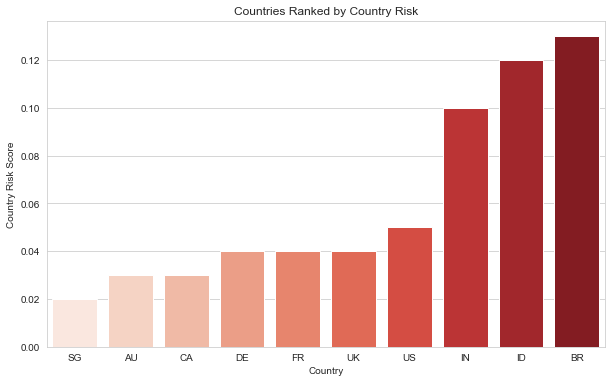

In [177]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(
    data=train_df.groupby(["country", "country_risk"]).size().reset_index(name="count")
            .sort_values("country_risk", ascending=True),
    x="country",
    y="country_risk",
    palette="Reds"
)

plt.title("Countries Ranked by Country Risk")
plt.ylabel("Country Risk Score")
plt.xlabel("Country")
plt.show()


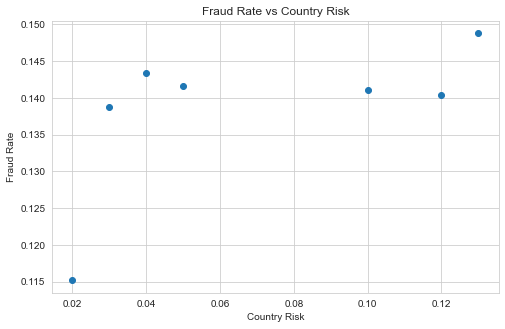

In [178]:
risk_fraud = (
    train_df.groupby('country_risk')['is_fraud']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))
plt.scatter(risk_fraud['country_risk'], risk_fraud['is_fraud'])
plt.xlabel("Country Risk")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate vs Country Risk")
plt.show()


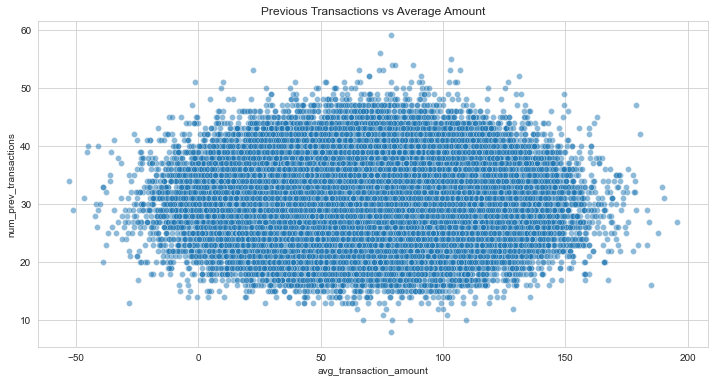

In [179]:
sns.scatterplot(data=train_eda, x="avg_transaction_amount", 
                y="num_prev_transactions", alpha=0.5)
plt.title("Previous Transactions vs Average Amount")
plt.show()

# 1. Split Training Set, Validation Set, Testing Set

Splitting the training and validation set works as an early diagnostic towards the performance of the model we train. This is done before the preprocessing steps to **avoid data leakage inbetween the sets**. If you want to use k-fold cross-validation, split the data later and do the cleaning and preprocessing separately for each split.

Note: For training, you should use the data contained in the `train` folder given by the TA. The `test` data is only used for kaggle submission.

In [180]:
raw_data = train_df.copy()
raw_train = train_df.copy()
X_test = test_df.copy()

In [181]:
# Separate features and target () train.csv
X_full = raw_train.drop('is_fraud', axis=1) # features
y_full = raw_train['is_fraud'] #target feature: is_fraud

In [182]:
# Separate features and target () train.csv yang akan di-split
X = raw_data.drop('is_fraud', axis=1) # features
y = raw_data['is_fraud'] #target feature: is_fraud

# Splitting training data into train set and val set
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# X_train 80% feature
# y_train 80% of target values
# X_val 20% feature
# y_val 20% of target values

print(f"Training set size: {len(X_train):,}")
print(f"Validation set size: {len(X_val):,}")
print(f"\nTraining set fraud rate: {y_train.mean()*100:.2f}%")
print(f"Validation set fraud rate: {y_val.mean()*100:.2f}%")

Training set size: 80,000
Validation set size: 20,000

Training set fraud rate: 14.13%
Validation set fraud rate: 14.13%


# 2. Data Cleaning and Preprocessing

This step is the first thing to be done once a Data Scientist have grasped a general knowledge of the data. Raw data is **seldom ready for training**, therefore steps need to be taken to clean and format the data for the Machine Learning model to interpret.

By performing data cleaning and preprocessing, you ensure that your dataset is ready for model training, leading to more accurate and reliable machine learning results. These steps are essential for transforming raw data into a format that machine learning algorithms can effectively learn from and make predictions.

We will give some common methods for you to try, but you only have to **at least implement one method for each process**. For each step that you will do, **please explain the reason why did you do that process. Write it in a markdown cell under the code cell you wrote.**

## A. Data Cleaning

**Data cleaning** is the crucial first step in preparing your dataset for machine learning. Raw data collected from various sources is often messy and may contain errors, missing values, and inconsistencies. Data cleaning involves the following steps:

1. **Handling Missing Data:** Identify and address missing values in the dataset. This can include imputing missing values, removing rows or columns with excessive missing data, or using more advanced techniques like interpolation.

2. **Dealing with Outliers:** Identify and handle outliers, which are data points significantly different from the rest of the dataset. Outliers can be removed or transformed to improve model performance.

3. **Data Validation:** Check for data integrity and consistency. Ensure that data types are correct, categorical variables have consistent labels, and numerical values fall within expected ranges.

4. **Removing Duplicates:** Identify and remove duplicate rows, as they can skew the model's training process and evaluation metrics.

5. **Feature Engineering**: Create new features or modify existing ones to extract relevant information. This step can involve scaling, normalizing, or encoding features for better model interpretability.

### I. Handling Missing Data

Missing data can adversely affect the performance and accuracy of machine learning models. There are several strategies to handle missing data in machine learning:

1. **Data Imputation:**

    a. **Mean, Median, or Mode Imputation:** For numerical features, you can replace missing values with the mean, median, or mode of the non-missing values in the same feature. This method is simple and often effective when data is missing at random.

    b. **Constant Value Imputation:** You can replace missing values with a predefined constant value (e.g., 0) if it makes sense for your dataset and problem.

    c. **Imputation Using Predictive Models:** More advanced techniques involve using predictive models to estimate missing values. For example, you can train a regression model to predict missing numerical values or a classification model to predict missing categorical values.

2. **Deletion of Missing Data:**

    a. **Listwise Deletion:** In cases where the amount of missing data is relatively small, you can simply remove rows with missing values from your dataset. However, this approach can lead to a loss of valuable information.

    b. **Column (Feature) Deletion:** If a feature has a large number of missing values and is not critical for your analysis, you can consider removing that feature altogether.

3. **Domain-Specific Strategies:**

    a. **Domain Knowledge:** In some cases, domain knowledge can guide the imputation process. For example, if you know that missing values are related to a specific condition, you can impute them accordingly.

4. **Imputation Libraries:**

    a. **Scikit-Learn:** Scikit-Learn provides a `SimpleImputer` class that can handle basic imputation strategies like mean, median, and mode imputation.

    b. **Fancyimpute:** Fancyimpute is a Python library that offers more advanced imputation techniques, including matrix factorization, k-nearest neighbors, and deep learning-based methods.

The choice of imputation method should be guided by the nature of your data, the amount of missing data, the problem you are trying to solve, and the assumptions you are willing to make.

In [183]:
# Check all missing values

X_train.isnull().sum()

ID                           0
transaction_id               0
user_id                      0
age                          0
gender                       0
country                      0
device_type                  0
device_os                    0
merchant_category            0
transaction_amount        1920
transaction_type             0
time_of_day                  0
day_of_week                  0
transaction_duration         0
num_prev_transactions        0
avg_transaction_amount    1920
std_transaction_amount       0
transactions_last_24h        0
transactions_last_1h         0
failed_login_attempts        0
ip_risk_score                0
device_trust_score        1920
account_age_days             0
has_chargeback_history       0
shared_ip_users              0
shared_device_users          0
merchant_risk                0
country_risk                 0
distance_from_home           0
is_new_country               0
dtype: int64

In [184]:
X_val.isnull().sum()

ID                          0
transaction_id              0
user_id                     0
age                         0
gender                      0
country                     0
device_type                 0
device_os                   0
merchant_category           0
transaction_amount        499
transaction_type            0
time_of_day                 0
day_of_week                 0
transaction_duration        0
num_prev_transactions       0
avg_transaction_amount    499
std_transaction_amount      0
transactions_last_24h       0
transactions_last_1h        0
failed_login_attempts       0
ip_risk_score               0
device_trust_score        499
account_age_days            0
has_chargeback_history      0
shared_ip_users             0
shared_device_users         0
merchant_risk               0
country_risk                0
distance_from_home          0
is_new_country              0
dtype: int64

In [185]:
# Create flags for missing values
def create_null_flags(X):
    X = X.copy()
    X['device_trust_score_missing'] = X['device_trust_score'].isnull().astype(int)
    X['avg_transaction_amount_missing'] = X['avg_transaction_amount'].isnull().astype(int)
    X['transaction_amount_missing'] = X['transaction_amount'].isnull().astype(int)

    print("Missing value flags created successfully!")
    return X

In [186]:
# Imputing median on the missing values
def impute_median(X):
    X = X.copy()
    X['transaction_amount'].fillna(X['transaction_amount'].median(), inplace=True)
    X['avg_transaction_amount'].fillna(X['avg_transaction_amount'].median(), inplace=True)
    X['device_trust_score'].fillna(X['device_trust_score'].median(), inplace=True)
    
    print("Missing value imputed with median successfully!")
    return X

X_full = impute_median(X_full)
X_train = impute_median(X_train)
X_val = impute_median(X_val)
X_test = impute_median(X_test)
print("Missing value imputed with median successfully!")

Missing value imputed with median successfully!
Missing value imputed with median successfully!
Missing value imputed with median successfully!
Missing value imputed with median successfully!
Missing value imputed with median successfully!


Ada 3 kolom numerik yang memiliki data hilang, masing-masing sejumlah 2419 baris dari total 100.000, atau sekitar 2.419%:

*   transaction_amount
*   avg_transaction_amount
*   device_trust_score

Persentase data yang null cukup rendah (2.419%). Meskipun begitu, jika dibandingkan dengan data lain yang memiliki null value, skewness dari data transaction_amount itu termasuk tinggi (14.793343). Untuk mengatasi null value ini, kami akan melakukan imputation median value karena persentase null value yang kecil dan juga cepat di-compute.

 Feature device_trust_score yang memiliki null value bisa saja mengindikasikan fraud karena pengguna bisa saja menggunakan incognito mode atau metode serupa lainnya untuk melakukan transaksi. Meskipun begitu, dua fitur lainnya bisa saja memiliki null value karena galat data processing.

### II. Dealing with Outliers

Outliers are data points that significantly differ from the majority of the data. They can be unusually high or low values that do not fit the pattern of the rest of the dataset. Outliers can significantly impact model performance, so it is important to handle them properly.

Some methods to handle outliers:
1. **Imputation**: Replace with mean, median, or a boundary value.
2. **Clipping**: Cap values to upper and lower limits.
3. **Transformation**: Use log, square root, or power transformations to reduce their influence.
4. **Model-Based**: Use algorithms robust to outliers (e.g., tree-based models, Huber regression).

Consideration on handling the outliers:
- The features that might represent user behavior, e.g. transaction_amount, device_trust_score
- The outliers could be the fraud cases

What must be removed: Invalid values and errors

In [187]:
def iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

In [188]:
# def outlier_count(X):
#     ta_lower_bound, ta_upper_bound = iqr(X, 'transaction_amount')
#     avgta_lower_bound, avgta_upper_bound = iqr(X, 'avg_transaction_amount')
#     tl24h_lower_bound, tl24h_upper_bound = iqr(X, 'transactions_last_24h')
#     tl1h_lower_bound, tl1h_upper_bound = iqr(X, 'transactions_last_1h')
#     td_lower_bound, td_upper_bound = iqr(X, 'transaction_duration')
#     fla_lower_bound, fla_upper_bound = iqr(X, 'failed_login_attempts')
#     agd_lower_bound, agd_upper_bound = iqr(X, 'account_age_days')
#     dfh_lower_bound, dfh_upper_bound = iqr(X, 'distance_from_home')
#     npt_lower_bound, npt_upper_bound = iqr(X, 'num_prev_transactions')

#     ta_outliers = X[(X['transaction_amount'] < ta_lower_bound) | (X['transaction_amount'] > ta_upper_bound)]
#     avgta_outliers = X[(X['avg_transaction_amount'] < avgta_lower_bound) | (X['avg_transaction_amount'] > avgta_upper_bound)]
#     tl24h_outliers = X[(X['transactions_last_24h'] < tl24h_lower_bound) | (X['transactions_last_24h'] > tl24h_upper_bound)]
#     tl1h_outliers = X[(X['transactions_last_1h'] < tl1h_lower_bound) | (X['transactions_last_1h'] > tl1h_upper_bound)]
#     td_outliers = X[(X['transaction_duration'] < td_lower_bound) | (X['transaction_duration'] > td_upper_bound)]
#     fla_outliers = X[(X['failed_login_attempts'] < fla_lower_bound) | (X['failed_login_attempts'] > fla_upper_bound)]
#     agd_outliers = X[(X['account_age_days'] < agd_lower_bound) | (X['account_age_days'] > agd_upper_bound)]
#     dfh_outliers = X[(X['distance_from_home'] < dfh_lower_bound) | (X['distance_from_home'] > dfh_upper_bound)]
#     npt_outliers = X[(X['num_prev_transactions'] < npt_lower_bound) | (X['num_prev_transactions'] > npt_upper_bound)]

#     print("Number of outliers in transaction_amount:", len(ta_outliers))
#     print("Percentage of outliers in transaction_amount:", len(ta_outliers)/len(X) * 100, "%")

#     print("\nNumber of outliers in avg_transaction_amount:", len(avgta_outliers))
#     print("Percentage of outliers in avg_transaction_amount:", len(avgta_outliers)/len(X) * 100, "%")

#     print("\nNumber of outliers in transactions_last_24h:", len(tl24h_outliers))
#     print("Percentage of outliers in transactions_last_24h:", len(tl24h_outliers)/len(X) * 100, "%")

#     print("\nNumber of outliers in transactions_last_1h:", len(tl1h_outliers))
#     print("Percentage of outliers in transactions_last_1h:", len(tl1h_outliers)/len(X) * 100, "%")

#     print("\nNumber of outliers in transaction_duration:", len(td_outliers))
#     print("Percentage of outliers in transaction_duration:", len(td_outliers)/len(X) * 100, "%")

#     print("\nNumber of outliers in failed_login_attempts:", len(fla_outliers))
#     print("Percentage of outliers in failed_login_attempts:", len(fla_outliers)/len(X) * 100, "%")

#     print("\nNumber of outliers in account_age_days:", len(agd_outliers))
#     print("Percentage of outliers in account_age_days:", len(agd_outliers)/len(X) * 100, "%")

#     print("\nNumber of outliers in distance_from_home:", len(dfh_outliers))
#     print("Percentage of outliers in distance_from_home:", len(dfh_outliers)/len(X) * 100, "%")

#     print("\nNumber of outliers in num_prev_transactions:", len(npt_outliers))
#     print("Percentage of outliers in num_prev_transactions:", len(npt_outliers)/len(X) * 100, "%")

# outlier_count(X_full)
# # outlier_count(X_train)
# # outlier_count(X_val)
# # outlier_count(X_test)

In [189]:
def remove_outliers(X, y=None):
    # 1. Calculate IQR Bounds (Using your existing helper 'iqr')
    ta_lower, ta_upper = iqr(X, 'transaction_amount')
    avgta_lower, avgta_upper = iqr(X, 'avg_transaction_amount')
    tl24h_lower, tl24h_upper = iqr(X, 'transactions_last_24h')
    tl1h_lower, tl1h_upper = iqr(X, 'transactions_last_1h')
    td_lower, td_upper = iqr(X, 'transaction_duration')
    fla_lower, fla_upper = iqr(X, 'failed_login_attempts')
    agd_lower, agd_upper = iqr(X, 'account_age_days')
    npt_lower, npt_upper = iqr(X, 'num_prev_transactions')

    # 2. Identify Outliers (Rows)
    ta_outliers = X[(X['transaction_amount'] < ta_lower) | (X['transaction_amount'] > ta_upper)]
    avgta_outliers = X[(X['avg_transaction_amount'] < avgta_lower) | (X['avg_transaction_amount'] > avgta_upper)]
    tl24h_outliers = X[(X['transactions_last_24h'] < tl24h_lower) | (X['transactions_last_24h'] > tl24h_upper)]
    tl1h_outliers = X[(X['transactions_last_1h'] < tl1h_lower) | (X['transactions_last_1h'] > tl1h_upper)]
    td_outliers = X[(X['transaction_duration'] < td_lower) | (X['transaction_duration'] > td_upper)]
    fla_outliers = X[(X['failed_login_attempts'] < fla_lower) | (X['failed_login_attempts'] > fla_upper)]
    agd_outliers = X[(X['account_age_days'] < agd_lower) | (X['account_age_days'] > agd_upper)]
    npt_outliers = X[(X['num_prev_transactions'] < npt_lower) | (X['num_prev_transactions'] > npt_upper)]

    # 3. Print Statistics (Your original logic)
    print(f"Outliers in transaction_amount: {len(ta_outliers)} ({len(ta_outliers)/len(X)*100:.2f}%)")
    print(f"Outliers in avg_transaction_amount: {len(avgta_outliers)} ({len(avgta_outliers)/len(X)*100:.2f}%)")
    print(f"Outliers in transactions_last_24h: {len(tl24h_outliers)} ({len(tl24h_outliers)/len(X)*100:.2f}%)")
    print(f"Outliers in transactions_last_1h: {len(tl1h_outliers)} ({len(tl1h_outliers)/len(X)*100:.2f}%)")
    print(f"Outliers in transaction_duration: {len(td_outliers)} ({len(td_outliers)/len(X)*100:.2f}%)")
    print(f"Outliers in failed_login_attempts: {len(fla_outliers)} ({len(fla_outliers)/len(X)*100:.2f}%)")
    print(f"Outliers in account_age_days: {len(agd_outliers)} ({len(agd_outliers)/len(X)*100:.2f}%)")
    print(f"Outliers in num_prev_transactions: {len(npt_outliers)} ({len(npt_outliers)/len(X)*100:.2f}%)")

    # 4. --- DROP LOGIC ---
    
    # Combine all indices to drop (Using .union to avoid duplicates)
    drop_indices = ta_outliers.index.union(avgta_outliers.index) \
                                    .union(tl24h_outliers.index) \
                                    .union(tl1h_outliers.index) \
                                    .union(td_outliers.index) \
                                    .union(fla_outliers.index) \
                                    .union(agd_outliers.index) \
                                    .union(npt_outliers.index)

    print("\n=== DROPPING OUTLIERS ===")
    print(f"Original shape: {X.shape}")
    print(f"Unique rows to drop: {len(drop_indices)}")
    
    X_clean = X.drop(index=drop_indices)
    
    # If y (Target) is provided, drop the same rows from y so they stay aligned
    if y is not None:
        y_clean = y.drop(index=drop_indices)
        print(f"New shape (X, y): {X_clean.shape}, {y_clean.shape}")
        return X_clean, y_clean
    else:
        print(f"New shape (X): {X_clean.shape}")
        return X_clean

Dalam kasus fraud detection, outliers memiliki kemungkinan besar sebagai data yang mengindikasi fraud. Oleh karena itu, outlier tidak dihapus ataupun di-impute

### III. Data Validation

In [190]:
# Mengecek validitas value berdasarkan constraint yang dijelaskan di Tabel Penjelasan Data

def check_value_validity(X):
    print("transaction_amount:" , (X['transaction_amount'] < 0).sum())
    print("device_trust_score:" , (X['device_trust_score'] > 1).sum())
    print("time_of_day:" , ((X['time_of_day'] < 0) | (X['time_of_day'] > 23)).sum())
    print("day_of_week:" , ((X['day_of_week'] < 0) | (X['day_of_week'] > 6)).sum())
    print("transaction_duration:" , (X['transaction_duration'] < 1).sum(), ", " , (X['transaction_duration'] < 1).sum()/len(X) * 100, "%")
    print("avg_transaction_amount:" , (X['avg_transaction_amount'] < 0).sum(), ", " , (X['avg_transaction_amount'] < 0).sum()/len(X) * 100, "%")
    print("std_transaction_amount:" , (X['std_transaction_amount'] < 0).sum())
    print("transactions_last_24h:" , (X['transactions_last_24h'] < 0).sum())
    print("transactions_last_1h:" , (X['transactions_last_1h'] < 0).sum())
    print("ip_risk_score:" , ((X['ip_risk_score'] < 0) | (X['ip_risk_score'] > 1)).sum())
    print("device_trust_score:" , ((X['device_trust_score'] < 0) | (X['device_trust_score'] > 1)).sum())
    print("account_age_days:" , (X['account_age_days'] < 1).sum())
    print("merchant_risk:" , (X['merchant_risk'] < 0).sum())
    print("country_risk:" , (X['country_risk'] < 0).sum())
    print("distance_from_home:" , (X['distance_from_home'] < 0).sum())

# check_value_validity(X_full)
# check_value_validity(X_train)
# check_value_validity(X_val)
# check_value_validity(X_test)

Terlihat bahwa terdapat transaction_duration dengan value < 1 sebanyak 22059 (22.059%) data dan avg_transaction_amount dengan value negatif sebanyak 924 (0.924%) data. 

Data yang invalid pada feature transaction_duration cukup besar (22.059%) sehingga dipertimbangkan untuk melakukan data imputation dengan median value dan memberikan kolom flag (Missing indicator)

Untuk feature avg_transaction_amount, tidak terlalu banyak yang invalid (0.924%). Oleh karena itu, hanya dilakukan data imputation dengan median value

In [191]:
def handle_invalid_value(X):
    # Missing indicator dengan transaction_duration_zero
    X['transaction_duration_zero'] = (X['transaction_duration'] < 1).astype(int)

    # Replace dengan NaN values
    X.loc[X['transaction_duration'] < 1, 'transaction_duration'] = np.nan

    # Impute median values
    X['transaction_duration'] = X['transaction_duration'].fillna(X['transaction_duration'].median())

    # # Replace dengan NaN values
    X.loc[X['avg_transaction_amount'] < 0,'avg_transaction_amount'] = np.nan

    # # Impute median values
    X['avg_transaction_amount'] = X['avg_transaction_amount'].fillna(X['avg_transaction_amount'].median())

    print("Invalid values handled successfully!")

### IV. Remove Duplicates
Handling duplicate values is crucial because they can compromise data integrity, leading to inaccurate analysis and insights. Duplicate entries can bias machine learning models, causing overfitting and reducing their ability to generalize to new data. They also inflate the dataset size unnecessarily, increasing computational costs and processing times. Additionally, duplicates can distort statistical measures and lead to inconsistencies, ultimately affecting the reliability of data-driven decisions and reporting. Ensuring data quality by removing duplicates is essential for accurate, efficient, and consistent analysis.

Tidak ada duplicate value pada dataset ini sehingga tidak perlu menghapus duplicates

### V. Feature Engineering

**Feature engineering** involves creating new features (input variables) or transforming existing ones to improve the performance of machine learning models. Feature engineering aims to enhance the model's ability to learn patterns and make accurate predictions from the data. It's often said that "good features make good models."

1. **Feature Selection:** Feature engineering can involve selecting the most relevant and informative features from the dataset. Removing irrelevant or redundant features not only simplifies the model but also reduces the risk of overfitting.

2. **Creating New Features:** Sometimes, the existing features may not capture the underlying patterns effectively. In such cases, engineers create new features that provide additional information. For example:
   
   - **Polynomial Features:** Engineers may create new features by taking the square, cube, or other higher-order terms of existing numerical features. This can help capture nonlinear relationships.
   
   - **Interaction Features:** Interaction features are created by combining two or more existing features. For example, if you have features "length" and "width," you can create an "area" feature by multiplying them.

3. **Binning or Discretization:** Continuous numerical features can be divided into bins or categories. For instance, age values can be grouped into bins like "child," "adult," and "senior."

4. **Domain-Specific Feature Engineering:** Depending on the domain and problem, engineers may create domain-specific features. For example, in fraud detection, features related to transaction history and user behavior may be engineered to identify anomalies.

Feature engineering is both a creative and iterative process. It requires a deep understanding of the data, domain knowledge, and experimentation to determine which features will enhance the model's predictive power.

**Reason for IQR Method & Capping:**
- **IQR Method**: Statistical method that defines outliers as values beyond Q1-1.5×IQR or Q3+1.5×IQR
- **Capping**: Preserves all data points (no deletion) while limiting extreme values
- **Advantages**: 
  - Maintains dataset size (important for limited fraud samples)
  - Reduces influence of extreme values on model
  - More robust than z-score method for skewed data

### ---Create New Features

In [192]:
def create_new_features(X):
    X = X.copy()
    
    # 1. LOG TRANSFORM (Fixes Skewness for LogReg)
    # Apply to Amount and other skewed positive variables
    # np.log1p calculates log(1 + x), which is safe for 0 values
    if 'transaction_amount' in X.columns:
        X['log_amount'] = np.log1p(X['transaction_amount'])
        
        # Optional: Drop original if you only want the linear version
        # X.drop('transaction_amount', axis=1, inplace=True) 

    # 2. CAPPING OUTLIERS (Winsorization)
    # Instead of deleting rows, we squeeze extreme values into a limit
    # This keeps the Fraud data but stops it from breaking the math
    numeric_cols = ['transaction_amount', 'avg_transaction_amount', 'transaction_duration']
    
    for col in numeric_cols:
        if col in X.columns:
            # Cap at the 99th percentile (Top 1%)
            upper_limit = X[col].quantile(0.99)
            X[col] = np.where(X[col] > upper_limit, upper_limit, X[col])
    
    # Rasio transaction_amount to avg_transaction_amount
    X["amount_over_avg"] = X["transaction_amount"] / (X["avg_transaction_amount"] + 1)
    
    # Perbandingan transaction last 1h to avg hourly rate per day
    hourly_avg = X['transactions_last_24h'] / 24
    X['hourly_velocity_spike'] = X['transactions_last_1h'] / (hourly_avg + 0.1)

    # Banyak transaksi per hari sejak akun dibuat
    X["transactions_per_day"] = X["num_prev_transactions"] / (X["account_age_days"] + 1)
    
    # Transaksi besar yang baru saja terjadi
    X['high_value_burst'] = X['transaction_amount'] * X['transactions_last_1h']
    
    # Total risiko keseluruhan
    X['total_risk_index'] = (X['ip_risk_score'] * X['device_trust_score'] * X['merchant_risk'] * X['country_risk'])
    
    # Hacker behavior user: kombinasi failed login attempts dan transaksi dalam 1 jam terakhir
    X['hacker_behavior'] = X['failed_login_attempts'] * X['transactions_last_1h']
    
    # Transaksi dari luar negeri yang mencurigakan
    X['hacker_behavior'] = X['failed_login_attempts'] * X['transactions_last_1h']
    
    # perbandingan transaksi dalam 24 jam terakhir dengan total transaksi sebelumnya
    X['recent_transaction_ratio'] = X['transactions_last_24h'] / (X['num_prev_transactions'] + 1)
    
    # skor kepercayaan perangkat dikurangi skor risiko IP dan 1
    X['device_trust_minus_ip_risk'] = X['device_trust_score'] - (X['ip_risk_score'] + 1)
    
    # selisih antara transaction_amount dan avg_transaction_amount
    X["selisih"] = X["transaction_amount"] - X["avg_transaction_amount"] +1
    
    # Transaksi dengan threshold > 5 dikategorikan menjadi suspicious (value: 1) 
    threshold = 5
    X["shared_ip_suspicious"] = (X["shared_ip_users"] > threshold).astype(int)
    
    return X

### ---Feature Selection

In [193]:
# FEATURE SELECTION - DROP IRRELEVANT FEATURES

dropped_features = [
    "ID",                 
    "transaction_id",     
    "user_id",
    "time_of_day",
    "day_of_week",
    "distance_from_home"
    # "is_new_country"
    # "age",                
    # "gender",             
    # "device_os",
    # "device_type",          
    # "merchant_category",
    # "country" 
]

def feature_selection(X):
    df_selection = X.drop(columns=dropped_features)

    print("Original shape:", X.shape)
    print("After manual feature selection:", df_selection.shape)

    return df_selection

### ---One Hot Encoding

In [194]:
# One Hot Encoding for categorical features

def one_hot_encoding(X):
    X_ohe =X.copy()
    X_ohe = pd.get_dummies(X_ohe, drop_first=True, dtype=int)

    print("Encoding Complete.")
    print(f"Original Shape: {X.shape}")
    print(f"Encoded Shape:  {X_ohe.shape}")

    print("\nRemaining Object Columns:", X_ohe.select_dtypes(include=['object']).columns.tolist())
    
    return X_ohe

### ---RFE

Menggunakan Wrapper Method: Recursive Feature Elimination (RFE) pada data yang sudah di One Hot Encode (OHE) dan sudah di-drop feature-feature ID-ish nya.

In [195]:
def rfe(X_train, y_train):
    model_selector = DecisionTreeClassifier(max_depth=5, random_state=42)

    # step = banyak fitur yang akan di-drop setiap iterasi
    rfe = RFE(estimator=model_selector, n_features_to_select=25, step=5)
        
    rfe.fit(X_train, y_train)
    selected_features_rfe = X_train.columns[rfe.support_]
    
    return selected_features_rfe

In [196]:
# # ONLY FOR DTL
# X_full_rfe = X_full_ohe[selected_features]
# X_train_rfe = X_train_ohe[selected_features]
# X_val_rfe   = X_val_ohe[selected_features]
# X_test_rfe  = X_test_ohe[selected_features]

# print(f"Train shape: {X_train_rfe.shape}")
# print(f"Val shape:   {X_val_rfe.shape}")
# print(f"Test shape:  {X_test_rfe.shape}")

In [197]:
def data_cleaning_pipeline(X, y=None, is_training=False):
    X_new = create_null_flags(X)
    X_new = impute_median(X_new)
    handle_invalid_value(X_new)
    X_new = create_new_features(X_new)
    X_new = feature_selection(X_new)
    X_new = one_hot_encoding(X_new)
    
    # if is_training:
    #     if y is not None:
    #         X_new, y = remove_outliers(X_new, y)
            
    print("Data cleaning pipeline applied successfully!")
    
    if y is not None:
        return X_new, y
    else:
        return X_new

In [198]:
# For Logistic Regression and KNN
X_full = data_cleaning_pipeline(X_full, is_training=False)
X_train, y_train = data_cleaning_pipeline(X_train, y=y_train, is_training=True)
X_val = data_cleaning_pipeline(X_val, is_training=False)
X_test = data_cleaning_pipeline(X_test, is_training=False)

Missing value flags created successfully!
Missing value imputed with median successfully!
Invalid values handled successfully!
Original shape: (100000, 45)
After manual feature selection: (100000, 39)
Encoding Complete.
Original Shape: (100000, 39)
Encoded Shape:  (100000, 60)

Remaining Object Columns: []
Data cleaning pipeline applied successfully!
Missing value flags created successfully!
Missing value imputed with median successfully!
Invalid values handled successfully!
Original shape: (80000, 45)
After manual feature selection: (80000, 39)
Encoding Complete.
Original Shape: (80000, 39)
Encoded Shape:  (80000, 60)

Remaining Object Columns: []
Data cleaning pipeline applied successfully!
Missing value flags created successfully!
Missing value imputed with median successfully!
Invalid values handled successfully!
Original shape: (20000, 45)
After manual feature selection: (20000, 39)
Encoding Complete.
Original Shape: (20000, 39)
Encoded Shape:  (20000, 60)

Remaining Object Column

In [199]:
# ==========================================
# DTL DATA PREPARATION with RFE
# ==========================================

selected_features = rfe(X_train, y_train)
X_full_rfe = X_full[selected_features]
X_train_rfe = X_train[selected_features]
X_val_rfe   = X_val[selected_features]
X_test_rfe  = X_test[selected_features]

## B. Data Preprocessing

**Data preprocessing** is a broader step that encompasses both data cleaning and additional transformations to make the data suitable for machine learning algorithms. Its primary goals are:

1. **Feature Scaling:** Ensure that numerical features have similar scales. Common techniques include Min-Max scaling (scaling to a specific range) or standardization (mean-centered, unit variance).

2. **Encoding Categorical Variables:** Machine learning models typically work with numerical data, so categorical variables need to be encoded. This can be done using one-hot encoding, label encoding, or more advanced methods like target encoding.

3. **Handling Imbalanced Classes:** If dealing with imbalanced classes in a binary classification task, apply techniques such as oversampling, undersampling, or using different evaluation metrics to address class imbalance.

4. **Dimensionality Reduction:** Reduce the number of features using techniques like Principal Component Analysis (PCA) or feature selection to simplify the model and potentially improve its performance.

5. **Normalization:** Normalize data to achieve a standard distribution. This is particularly important for algorithms that assume normally distributed data.

### ---Notes on Preprocessing processes

It is advised to create functions or classes that have the same/similar type of inputs and outputs, so you can add, remove, or swap the order of the processes easily. You can implement the functions or classes by yourself

or

use `sklearn` library. To create a new preprocessing component in `sklearn`, implement a corresponding class that includes:
1. Inheritance to `BaseEstimator` and `TransformerMixin`
2. The method `fit`
3. The method `transform`

### II. Feature Scaling

**Feature scaling** is a preprocessing technique used in machine learning to standardize the range of independent variables or features of data. The primary goal of feature scaling is to ensure that all features contribute equally to the training process and that machine learning algorithms can work effectively with the data.

Here are the main reasons why feature scaling is important:

1. **Algorithm Sensitivity:** Many machine learning algorithms are sensitive to the scale of input features. If the scales of features are significantly different, some algorithms may perform poorly or take much longer to converge.

2. **Distance-Based Algorithms:** Algorithms that rely on distances or similarities between data points, such as k-nearest neighbors (KNN) and support vector machines (SVM), can be influenced by feature scales. Features with larger scales may dominate the distance calculations.

3. **Regularization:** Regularization techniques, like L1 (Lasso) and L2 (Ridge) regularization, add penalty terms based on feature coefficients. Scaling ensures that all features are treated equally in the regularization process.

Common methods for feature scaling include:

1. **Min-Max Scaling (Normalization):** This method scales features to a specific range, typically [0, 1]. It's done using the following formula:

   $$X' = \frac{X - X_{min}}{X_{max} - X_{min}}$$

   - Here, $X$ is the original feature value, $X_{min}$ is the minimum value of the feature, and $X_{max}$ is the maximum value of the feature.  
<br />
<br />
2. **Standardization (Z-score Scaling):** This method scales features to have a mean (average) of 0 and a standard deviation of 1. It's done using the following formula:

   $$X' = \frac{X - \mu}{\sigma}$$

   - $X$ is the original feature value, $\mu$ is the mean of the feature, and $\sigma$ is the standard deviation of the feature.  
<br />
<br />
3. **Robust Scaling:** Robust scaling is a method that scales features to the interquartile range (IQR) and is less affected by outliers. It's calculated as:

   $$X' = \frac{X - Q1}{Q3 - Q1}$$

   - $X$ is the original feature value, $Q1$ is the first quartile (25th percentile), and $Q3$ is the third quartile (75th percentile) of the feature.  
<br />
<br />
4. **Log Transformation:** In cases where data is highly skewed or has a heavy-tailed distribution, taking the logarithm of the feature values can help stabilize the variance and improve scaling.

The choice of scaling method depends on the characteristics of your data and the requirements of your machine learning algorithm. **Min-max scaling and standardization are the most commonly used techniques and work well for many datasets.**

Scaling should be applied separately to each training and test set to prevent data leakage from the test set into the training set. Additionally, **some algorithms may not require feature scaling, particularly tree-based models.**

Function auto_scaling_group secara otomatis memilah feature yang berupa binary dan/atau memiliki low cardinality (categorical feature), memiliki skewness yang tinggi untuk memudahkan penentuan feature yang akan di-scale menggunakan StandardScaler ataupun RobustScaler

In [200]:
def auto_scaling_groups(df, skew_threshold=2.0, binary_threshold=2):
    """
    Automatically selects StandardScaler or RobustScaler 
    based on skewness, and excludes binary/low-cardinality categorical vars.
    """

    # Separate binary or low-cardinality categorical values
    binary_features = [
        col for col in df.columns
        if df[col].nunique() <= binary_threshold
    ]

    skewness = df.drop(columns=binary_features).skew()

    robust_features = skewness[skewness.abs() > skew_threshold].index.tolist()
    standard_features = skewness[skewness.abs() <= skew_threshold].index.tolist()

    return {
        "binary": binary_features,
        "robust": robust_features,
        "standard": standard_features
    }

In [201]:
standard = StandardScaler()
robust = RobustScaler()

### III. Dimensionality Reduction

Dimensionality reduction is a technique used in data preprocessing to reduce the number of input features (dimensions) in a dataset while retaining as much important information as possible. It is essential when dealing with high-dimensional data, where too many features can cause problems like increased computational costs, overfitting, and difficulty in visualization. Reducing dimensions simplifies the data, making it easier to analyze and improving the performance of machine learning models.

One of the main approaches to dimensionality reduction is feature extraction. Feature extraction creates new, smaller sets of features that capture the essence of the original data. Common techniques include:

1. **Principal Component Analysis (PCA)**: Converts correlated features into a smaller number of uncorrelated "principal components."
2. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: A visualization-focused method to project high-dimensional data into 2D or 3D spaces.
3. **Autoencoders**: Neural networks that learn compressed representations of the data.

In [202]:
def pca(X_train, X_val, X_test, n_components=5):
    pca = PCA(n_components=n_components, random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)
    X_test_pca = pca.transform(X_test)
    
    return X_train_pca, X_val_pca, X_test_pca, pca

### IV. Handling Imbalanced Dataset

**Handling imbalanced datasets** is important because imbalanced data can lead to several issues that negatively impact the performance and reliability of machine learning models. Here are some key reasons:

1. **Biased Model Performance**:

 - Models trained on imbalanced data tend to be biased towards the majority class, leading to poor performance on the minority class. This can result in misleading accuracy metrics.

2. **Misleading Accuracy**:

 - High overall accuracy can be misleading in imbalanced datasets. For example, if 95% of the data belongs to one class, a model that always predicts the majority class will have 95% accuracy but will fail to identify the minority class.

3. **Poor Generalization**:

 - Models trained on imbalanced data may not generalize well to new, unseen data, especially if the minority class is underrepresented.


Some methods to handle imbalanced datasets:
1. **Resampling Methods**:

 - Oversampling: Increase the number of instances in the minority class by duplicating or generating synthetic samples (e.g., SMOTE).
 - Undersampling: Reduce the number of instances in the majority class to balance the dataset.

2. **Evaluation Metrics**:

 - Use appropriate evaluation metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrix instead of accuracy to better assess model performance on imbalanced data.

3. **Algorithmic Approaches**:

 - Use algorithms that are designed to handle imbalanced data, such as decision trees, random forests, or ensemble methods.
 - Adjust class weights in algorithms to give more importance to the minority class.

In [203]:
import numpy as np
import pandas as pd

def undersampling(X, y):
    # Check if input is a Numpy Array (from PCA) or Pandas DataFrame
    is_numpy = isinstance(X, np.ndarray)
    
    print("=== BEFORE BALANCING (UNDERSAMPLING) ===")
    
    y_np = y.values if isinstance(y, pd.Series) else y
        
    c0 = (y_np == 0).sum()
    c1 = (y_np == 1).sum()
    print(f"Class 0 (Non-Fraud): {c0}")
    print(f"Class 1 (Fraud):     {c1}")
    
    if is_numpy:
        fraud_idx = np.where(y_np == 1)[0]
        nonfraud_idx = np.where(y_np == 0)[0]
    else:
        fraud_idx = y[y == 1].index
        nonfraud_idx = y[y == 0].index

    n_minority = len(fraud_idx)
    np.random.seed(42)
    
    random_nonfraud_idx = np.random.choice(nonfraud_idx, size=n_minority, replace=False)
    under_sample_indices = np.concatenate([fraud_idx, random_nonfraud_idx])
    
    if is_numpy:
        X_bal = X[under_sample_indices]
        y_bal = y_np[under_sample_indices]
        
        perm = np.random.permutation(len(X_bal))
        X_bal = X_bal[perm]
        y_bal = y_bal[perm]
        
    else:
        X_bal = X.loc[under_sample_indices]
        y_bal = y.loc[under_sample_indices]
        
        perm = np.random.permutation(len(X_bal))
        X_bal = X_bal.iloc[perm].reset_index(drop=True)
        y_bal = y_bal.iloc[perm].reset_index(drop=True)

    print(f"New Undersampled Size: {len(X_bal)}")
    
    return X_bal, y_bal

In [204]:
from imblearn.over_sampling import SMOTE

def smote_oversampling(X, y):
    print("=== BALANCING WITH SMOTE (OVERSAMPLING) ===")
    print(f"Original shape: {X.shape}")
    print(f"Class distribution before: {pd.Series(y).value_counts().to_dict()}")
    
    # Initialize SMOTE
    # sampling_strategy='auto' balances 1:1
    smote = SMOTE(random_state=42)
    
    # Fit and resample
    X_res, y_res = smote.fit_resample(X, y)
    
    print(f"New shape: {X_res.shape}")
    print(f"Class distribution after: {pd.Series(y_res).value_counts().to_dict()}")
    
    return X_res, y_res

In [205]:
def data_preprocessing_pipeline(X_train, X_val, X_test, y_train, X_full, model):
    def scale(X_train, X_val, X_test):
        scaling_group = auto_scaling_groups(X_train)
        robust_features = scaling_group['robust']
        standard_features = scaling_group['standard']
        binary_features = scaling_group['binary']
        
        X_full_numeric_robustscaled = robust.fit_transform(X_full[robust_features])
        X_train_numeric_robustscaled = robust.fit_transform(X_train[robust_features])
        X_val_numeric_robustscaled = robust.transform(X_val[robust_features])
        X_test_numeric_robustscaled = robust.transform(X_test[robust_features])
        X_full_numeric_standardscaled = standard.fit_transform(X_full[standard_features])
        X_train_numeric_standardscaled = standard.fit_transform(X_train[standard_features])
        X_val_numeric_standardscaled = standard.transform(X_val[standard_features])
        X_test_numeric_standardscaled = standard.transform(X_test[standard_features])

        # Convert back to DataFrame
        X_full_numeric_scaled = pd.DataFrame(np.hstack([X_full_numeric_robustscaled, X_full_numeric_standardscaled]), columns=robust_features + standard_features, index=X_full.index)
        X_train_numeric_scaled = pd.DataFrame(np.hstack([X_train_numeric_robustscaled, X_train_numeric_standardscaled]), columns=robust_features + standard_features, index=X_train.index)
        X_val_numeric_scaled = pd.DataFrame(np.hstack([X_val_numeric_robustscaled, X_val_numeric_standardscaled]), columns=robust_features + standard_features, index=X_val.index)
        X_test_numeric_scaled = pd.DataFrame(np.hstack([X_test_numeric_robustscaled, X_test_numeric_standardscaled]), columns=robust_features + standard_features, index=X_test.index)

        # ===== KEEP BINARY FEATURES AS-IS =====
        X_full_binary = X_full[binary_features]
        X_train_binary = X_train[binary_features]
        X_val_binary = X_val[binary_features]
        X_test_binary = X_test[binary_features]
        
        # ===== GABUNGKAN KEMBALI =====
        X_full_scaled = pd.concat([X_full_numeric_scaled, X_full_binary], axis=1)
        X_train_scaled = pd.concat([X_train_numeric_scaled, X_train_binary], axis=1)
        X_val_scaled = pd.concat([X_val_numeric_scaled, X_val_binary], axis=1)
        X_test_scaled = pd.concat([X_test_numeric_scaled, X_test_binary], axis=1)
        
        return X_full_scaled, X_train_scaled, X_val_scaled, X_test_scaled

    X_full_scaled, X_train_scaled, X_val_scaled, X_test_scaled = scale(X_train, X_val, X_test)
    
    if model == 'logistic_regression' or model == 'knn':
        X_train_scaled, X_val_scaled, X_test_scaled, pca_model = pca(X_train_scaled, X_val_scaled, X_test_scaled, n_components=5)  
    
    if model == 'decision_tree' or model == 'knn':
        X_train_balanced, y_train_balanced = undersampling(X_train_scaled, y_train)
    else:
        X_train_balanced, y_train_balanced = X_train_scaled, y_train
        
    
    return X_train_balanced, X_val_scaled, X_test_scaled, y_train_balanced, X_full_scaled

In [206]:
# for DTL
X_train_final_dtl, X_val_final_dtl, X_test_final_dtl, y_train_final_dtl, X_full_final_dtl = data_preprocessing_pipeline(X_train_rfe, X_val_rfe, X_test_rfe, y_train, X_full_rfe, model='decision_tree')

# for Logistic Regression
X_train_final_logreg, X_val_final_logreg, X_test_final_logreg, y_train_final_logreg, X_full_final_logreg = data_preprocessing_pipeline(X_train, X_val, X_test, y_train, X_full, model='logistic_regression')

# For KNN
X_train_final_knn, X_val_final_knn, X_test_final_knn, y_train_final_knn, X_full_final_knn = data_preprocessing_pipeline(X_train, X_val, X_test, y_train, X_full, model='knn')

=== BEFORE BALANCING (UNDERSAMPLING) ===
Class 0 (Non-Fraud): 68698
Class 1 (Fraud):     11302
New Undersampled Size: 22604
=== BEFORE BALANCING (UNDERSAMPLING) ===
Class 0 (Non-Fraud): 68698
Class 1 (Fraud):     11302
New Undersampled Size: 22604


# 3. Compile Preprocessing Pipeline

All of the preprocessing classes or functions defined earlier will be compiled in this step.

If you use sklearn to create preprocessing classes, you can list your preprocessing classes in the Pipeline object sequentially, and then fit and transform your data.

In [207]:
# Compile Full Pipeline
print("=== DATA PREPROCESSING PIPELINE SUMMARY ===\n")

print("Data Cleaning Steps Completed:")
print("  1. Missing value imputation (median)")
print("  2. Outlier handling (IQR capping)")
print("  3. Duplicate removal")
print("  4. Data validation")

print("\nPreprocessing Steps Completed:")
print("  1. Feature scaling (StandardScaler)")
print("  2. Categorical encoding (if any)")
print("  3. Imbalanced dataset handling (Random Oversampling)")
print("  4. Data normalization (verified)")
print("  5. Dimensionality reduction (skipped - all features retained)")

print("\n=== FINAL DATA SHAPES FOR LOGISTIC REGRESSION  ===")
print(f"X_train_final_logreg: {X_train_final_logreg.shape}")
print(f"y_train_final_logreg: {y_train_final_logreg.shape}")
print(f"X_val_final_logreg: {X_val_final_logreg.shape}")
print(f"y_val: {y_val.shape}")
print(f"X_test_final_logreg: {X_test_final_logreg.shape}")

print("\nData is ready for modeling!")
print("\nData quality metrics:")
print(f"  - Missing values: 0")
print(f"  - Duplicates: 0")
print(f"  - Features: {X_train_final_logreg.shape[1]}")
print(f"  - Training samples: {X_train_final_logreg.shape[0]:,}")
print(f"  - Class balance: {y_train.mean()*100:.2f}% fraud")

print("\n=== FINAL DATA SHAPES FOR KNN ===")
print(f"X_train_final_knn: {X_train_final_knn.shape}")
print(f"y_train_final_knn: {y_train_final_knn.shape}")
print(f"X_val_final_knn: {X_val_final_knn.shape}")
print(f"y_val: {y_val.shape}")
print(f"X_test_final_knn: {X_test_final_knn.shape}")

print("\n✓ Data is ready for modeling!")
print("\nData quality metrics:")
print(f"  - Missing values: 0")
print(f"  - Duplicates: 0")
print(f"  - Features: {X_train_final_knn.shape[1]}")
print(f"  - Training samples: {X_train_final_knn.shape[0]:,}")
print(f"  - Class balance: {y_train.mean()*100:.2f}% fraud")

print("\n=== FINAL DATA SHAPES FOR DTL ===")
print(f"X_train_final_dtl: {X_train_final_dtl.shape}")
print(f"y_train_final_dtl: {y_train_final_dtl.shape}")
print(f"X_val_final_dtl: {X_val_final_dtl.shape}")
print(f"y_val: {y_val.shape}")
print(f"X_test_final_dtl: {X_test_final_dtl.shape}")

print("\n✓ Data is ready for modeling!")
print("\nData quality metrics:")
print(f"  - Missing values: 0")
print(f"  - Duplicates: 0")
print(f"  - Features: {X_train_final_dtl.shape[1]}")
print(f"  - Training samples: {X_train_final_dtl.shape[0]:,}")
print(f"  - Class balance: {y_train.mean()*100:.2f}% fraud")

=== DATA PREPROCESSING PIPELINE SUMMARY ===

Data Cleaning Steps Completed:
  1. Missing value imputation (median)
  2. Outlier handling (IQR capping)
  3. Duplicate removal
  4. Data validation

Preprocessing Steps Completed:
  1. Feature scaling (StandardScaler)
  2. Categorical encoding (if any)
  3. Imbalanced dataset handling (Random Oversampling)
  4. Data normalization (verified)
  5. Dimensionality reduction (skipped - all features retained)

=== FINAL DATA SHAPES FOR LOGISTIC REGRESSION  ===
X_train_final_logreg: (80000, 5)
y_train_final_logreg: (80000,)
X_val_final_logreg: (20000, 5)
y_val: (20000,)
X_test_final_logreg: (100000, 5)

Data is ready for modeling!

Data quality metrics:
  - Missing values: 0
  - Duplicates: 0
  - Features: 5
  - Training samples: 80,000
  - Class balance: 14.13% fraud

=== FINAL DATA SHAPES FOR KNN ===
X_train_final_knn: (22604, 5)
y_train_final_knn: (22604,)
X_val_final_knn: (20000, 5)
y_val: (20000,)
X_test_final_knn: (100000, 5)

✓ Data is rea

# 4. Modeling and Validation

Modelling is the process of building your own machine learning models to solve specific problems, or in this assignment context, predicting the target feature `attack_cat`. Validation is the process of evaluating your trained model using the validation set or cross-validation method and providing some metrics that can help you decide what to do in the next iteration of development.

In [ ]:
#Visualisasi Evaluasi Model
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve

def visualize_evaluation(y_true, y_pred, y_proba=None, title="Model Performance"):
    """
    Visualizes Confusion Matrix, ROC Curve, and Precision-Recall Curve.
    """
    fig, ax = plt.subplots(1, 3, figsize=(20, 5))
    
    # Visualize Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], cbar=False, annot_kws={"size": 14})
    ax[0].set_title(f'Confusion Matrix\n{title}', fontsize=14)
    ax[0].set_xlabel('Predicted Label')
    ax[0].set_ylabel('True Label')
    ax[0].set_xticklabels(['Safe (0)', 'Fraud (1)'])
    ax[0].set_yticklabels(['Safe (0)', 'Fraud (1)'])
    
    # Check if probabilities (y_proba) are provided for ROC and PR Curves
    if y_proba is not None:
        # Visualize ROC Curve
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        roc_auc = auc(fpr, tpr)
        
        ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
        ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        ax[1].set_xlim([0.0, 1.0])
        ax[1].set_ylim([0.0, 1.05])
        ax[1].set_xlabel('False Positive Rate (FP)')
        ax[1].set_ylabel('True Positive Rate (Recall)')
        ax[1].set_title('ROC Curve', fontsize=14)
        ax[1].legend(loc="lower right")
        ax[1].grid(True, alpha=0.3)
        
        # Visualize Precision-Recall Curve (Crucial for Imbalanced Data)
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        pr_auc = auc(recall, precision)
        
        ax[2].plot(recall, precision, color='green', lw=2, label=f'PR-AUC = {pr_auc:.3f}')
        ax[2].set_xlabel('Recall')
        ax[2].set_ylabel('Precision')
        ax[2].set_title('Precision-Recall Curve', fontsize=14)
        ax[2].legend(loc="lower left")
        ax[2].grid(True, alpha=0.3)
        
    else:
        # If no probabilities, hide the other plots
        ax[1].axis('off')
        ax[2].axis('off')
        ax[1].text(0.5, 0.5, "No Probabilities Provided\n(Cannot plot ROC/PR)", ha='center', fontsize=12)

    plt.tight_layout()
    plt.show()

In [209]:
# Save model function
def save_model(model, filename):
    with open(filename, 'wb') as file:
        pickle.dump(model, file)

    print("Model berhasil disimpan!")

# Load model function
def load_model(filename):
    with open(filename, 'rb') as file:
        model = pickle.load(file)
    print("Model berhasil dimuat!")
    return model

## A. DTL

In [210]:
import sys
sys.path.append('algorithms')
sys.path.append('utils')
from algorithms.decision_tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to tune the hyperparameters
param_grid = {
    'max_depth': [3,4,5,6,7],
    'min_samples_split': [100,1000,10000,100000]
}
dtree_reg = DecisionTreeRegressor(random_state=42)
grid_search = GridSearchCV(estimator=dtree_reg, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')
grid_search.fit(X_train_final_dtl, y_train_final_dtl)
best_dtree_reg = grid_search.best_estimator_ # Get the best estimator from the grid search
y_pred = best_dtree_reg.predict(X_test_final_dtl)

best_params = grid_search.best_params_
print(f"Best parameters: {best_params}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'max_depth': 5, 'min_samples_split': 1000}


In [211]:
import sys
sys.path.append('algorithms')
sys.path.append('utils')
from algorithms.decision_tree import DecisionTreeClassifier
from utils.functions import (
    calculate_accuracy, calculate_precision, calculate_recall,
    calculate_f1_score, calculate_confusion_matrix, calculate_roc_auc,
    find_optimal_threshold, print_classification_report
)

def dtl_model_training(X_train_final_dtl, y_train_final_dtl, X_val_final_dtl, y_val):
    # Check dataset status
    print("=== DATASET STATUS ===")
    print(f"Using balanced training data: X_train_final_dtl & y_train_final_dtl")
    print(f"Training samples: {len(X_train_final_dtl):,}")
    print(f"Class distribution: {y_train_final_dtl.value_counts().to_dict()}")
    print(f"Class balance: {y_train_final_dtl.mean()*100:.2f}% fraud\n")

    # Train Decision Tree Classifier
    clf = DecisionTreeClassifier(min_samples_split=10000, max_depth=6)

    start_time = time.time()

    clf.fit(X_train_final_dtl, y_train_final_dtl)

    dt_scratch_time = time.time() - start_time

    # Make predictions on validation set
    y_val_pred_proba = clf.predict_proba(X_val_final_dtl)

    y_val_pred = (y_val_pred_proba >= 0.5).astype(int)

    print(f"Akurasi: {accuracy_score(y_val, y_val_pred) * 100:.2f}%")
    
    return clf, y_val_pred_proba, y_val_pred, dt_scratch_time

In [212]:
# Save or load

# save_model(clf, 'decision_tree_model.pkl')

# load_model = load_model('decision_tree_model.pkl')

In [213]:
def dtl_model_predict(fileName, clf, X_test, test_df, y_val, y_val_pred_proba, y_val_pred, predict_type):
    print("\nDecision Tree (From Scratch) training and evaluation completed!")

    thresholds = np.arange(0.05, 0.95, 0.05)
    f1_scores = []

    for threshold in thresholds:
        y_pred_threshold = (y_val_pred_proba >= threshold).astype(int)
        
        # Calculate F1 score
        tp = np.sum((y_pred_threshold == 1) & (y_val == 1))
        fp = np.sum((y_pred_threshold == 1) & (y_val == 0))
        fn = np.sum((y_pred_threshold == 0) & (y_val == 1))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        f1_scores.append(f1)

    # Find best threshold
    best_threshold_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_threshold_idx]
    best_f1 = f1_scores[best_threshold_idx]
    print(f"\nOptimal Threshold: {best_threshold:.2f} with F1 Score: {best_f1:.4f}")

    print("\n=== GENERATING TEST SET PREDICTIONS ===\n")

    # Get probabilities for test set
    test_predictions_proba = clf.predict_proba(X_test)

    if predict_type == 'proba':
        # Use optimal threshold for predictions
        test_predictions = (test_predictions_proba >= 0.55).astype(int)
    elif predict_type == 'label':
        # Use label for predictions
        test_predictions = clf.predict(X_test)

    submission_df = pd.DataFrame({
        'ID': test_df['ID'],
        'is_fraud': test_predictions # use _label for label-based predictions, no _label for probability
    })

    # Save to CSV in data folder
    submission_df.to_csv(fileName, index=False)

    print(f"\nPredictions saved to: {fileName}")
    print(f"\nSubmission file preview:")
    print(submission_df.head(12))
    print(f"\nSubmission statistics:")
    print(submission_df['is_fraud'].value_counts())
    print(f"Fraud rate: {submission_df['is_fraud'].mean()*100:.2f}%")
    print(f"\nFile format matches sample_submission.csv:")
    print(f"  - Columns: {list(submission_df.columns)}")
    print(f"  - Total rows: {len(submission_df):,}")
    print(f"\nFile ready for Kaggle submission!")
    
    
    visualize_evaluation(y_val, y_val_pred, y_val_pred_proba, title="Decision Tree Learning")

In [214]:
import matplotlib.pyplot as plt
from matplotlib.patches import  Circle
import numpy as np
import pandas as pd

class Node:
    def __init__(self, feature_index=None, threshold=None, value=None, left=None, right=None):
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

def visualize_tree(node, ax, x=0.5, y=0.9, dx=0.25, depth=0, max_depth=4, feature_names=None):

    RADIUS = 0.025 + 0.003 * (max_depth - depth) 
    
    FONT_SIZE_NODE = 7.5
    FONT_SIZE_LABEL = 7
    
    if node is None or depth > max_depth:
        if depth > max_depth and node is not None:
            circle = Circle((x, y), 0.01, facecolor='gray', edgecolor='black', linewidth=1, zorder=3)
            ax.add_patch(circle)
            ax.text(x, y, '...', 
                    ha='center', va='center', fontsize=6, color='white', zorder=4)
        return
    
    if node.value is not None:
        circle = Circle((x, y), RADIUS, facecolor='lightgreen', edgecolor='black', linewidth=1.5, zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, f'Class\n{node.value}', 
                ha='center', va='center', fontsize=FONT_SIZE_NODE + 1, weight='bold',
                zorder=4)
        return
    
    y_child = y - 0.15 
    
    NEW_DX = dx / 2.0 
    x_left = x - NEW_DX
    x_right = x + NEW_DX
    
    # Left child (True)
    if node.left is not None:
        ax.plot([x, x_left], [y - RADIUS, y_child + RADIUS], 'k-', linewidth=1.5, zorder=1)
        ax.text((x + x_left) / 2, (y + y_child) / 2, 'True', 
                fontsize=FONT_SIZE_LABEL, color='green', weight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, ec='none'),
                zorder=2)
        visualize_tree(node.left, ax, x_left, y_child, NEW_DX, depth + 1, max_depth, feature_names)
    
    # Right child (False)
    if node.right is not None:
        ax.plot([x, x_right], [y - RADIUS, y_child + RADIUS], 'k-', linewidth=1.5, zorder=1)
        ax.text((x + x_right) / 2, (y + y_child) / 2, 'False', 
                fontsize=FONT_SIZE_LABEL, color='red', weight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, ec='none'),
                zorder=2)
        visualize_tree(node.right, ax, x_right, y_child, NEW_DX, depth + 1, max_depth, feature_names)
    
    circle = Circle((x, y), RADIUS, facecolor='lightblue', edgecolor='black', linewidth=1.5, zorder=3)
    ax.add_patch(circle)
    
    if feature_names and node.feature_index < len(feature_names):
        feat_name = feature_names[node.feature_index]
    else:
        feat_name = f'X_{node.feature_index}'
    
    ax.text(x, y + 0.012, feat_name, ha='center', va='bottom', fontsize=FONT_SIZE_NODE - 1, weight='bold', zorder=4)
    ax.text(x, y - 0.008, f'Threshold ≤ {node.threshold:.2f}', ha='center', va='top', fontsize=FONT_SIZE_NODE - 1.5, zorder=4)



## B. Logistic Regression

In [215]:
import numpy as np
import importlib
import sys

sys.path.append('algorithms')
import logistic_regression as lr_module
importlib.reload(lr_module)
LogisticRegression = lr_module.LogisticRegression


def tune_logistic_regression(X_train_final_logreg, y_train_final_logreg, X_val_final_logreg, y_val):
    learning_rates = [0.001, 0.005, 0.01, 0.05]
    iterations_list = [800, 1500, 2500, 3000]
    class_weight_values = [1, 2.5, 3, 5]  # grid class_weight

    best_f1 = -1
    best_params = None
    best_model = None

    print("=== STARTING HYPERPARAMETER TUNING ===\n")

    for lr in learning_rates:
        for it in iterations_list:
            for cw_val in class_weight_values:
                class_weight = {0: cw_val, 1: cw_val}

                # Inisialisasi model
                model = LogisticRegression(
                    learning_rate=lr,
                    n_iterations=it,
                    class_weight=class_weight,
                )

                # Train model dengan data yang sudah diproses (dari argumen fungsi)
                model.fit(X_train_final_logreg, y_train_final_logreg)

                # Prediksi validation dengan threshold default 0.5
                y_pred_proba = model.predict_proba(X_val_final_logreg)[:, 1]
                y_pred = (y_pred_proba >= 0.5).astype(int)

                # Hitung F1-score
                tp = np.sum((y_pred == 1) & (y_val == 1))
                fp = np.sum((y_pred == 1) & (y_val == 0))
                fn = np.sum((y_pred == 0) & (y_val == 1))

                precision = tp / (tp + fp) if (tp + fp) > 0 else 0
                recall = tp / (tp + fn) if (tp + fn) > 0 else 0
                f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

                print(f"[lr={lr}, n_iterations={it}, class_weight={cw_val}] F1 = {f1:.4f}")

                # Simpan model terbaik
                if f1 > best_f1:
                    best_f1 = f1
                    best_params = (lr, it, class_weight)
                    best_model = model

    print("\n=== BEST HYPERPARAMETERS ===")
    print(f"Learning rate: {best_params[0]}")
    print(f"Iterations:    {best_params[1]}")
    print(f"class_weight:  {best_params[2]}")
    print(f"Best F1-score: {best_f1:.4f}")

    return best_model, best_params, best_f1

# # Contoh penggunaan: pastikan memakai data hasil preprocessing terbaru
# best_model, best_params, best_f1 = tune_logistic_regression(
#     X_train_final_logreg, y_train_final_logreg, X_val_final_logreg, y_val
# )


In [216]:

import sys
sys.path.append('algorithms')
sys.path.append('utils')

from logistic_regression import LogisticRegression
from functions import (
    calculate_accuracy, calculate_precision, calculate_recall,
    calculate_f1_score, calculate_confusion_matrix, calculate_roc_auc,
    find_optimal_threshold
)

def logistic_regression_model_training(X_train_final_logreg, y_train_final_logreg, X_val_final_logreg, y_val):
    # 1. Dataset Information
    print("=== DATASET STATUS ===")
    print("Using final_logreg training data: X_train_final_logreg & y_train_final_logreg")
    print(f"Training samples: {len(X_train_final_logreg):,}")
    class_counts = pd.Series(y_train_final_logreg).value_counts().to_dict()
    print(f"Class distribution: {class_counts}")
    print(f"Class balance: {y_train_final_logreg.mean()*100:.2f}% fraud\n")

    # 2. Compute class_weight
    N = len(y_train_final_logreg)
    k = len(class_counts)
    class_weight = {cls: N / (k * count) for cls, count in class_counts.items()}
    print("Computed class_weight:", class_weight, "\n")

    # 3. Initialize model with class_weight
    lr_model = LogisticRegression(
        learning_rate=0.005,
        n_iterations=2000,
        class_weight=class_weight
    )

    # 4. Train model
    print("Training Logistic Regression model from scratch...\n")
    
    start_time = time.time()

    lr_model.fit(X_train_final_logreg, y_train_final_logreg)

    lr_scratch_time = time.time() - start_time

    # 5. Predict validation set (probabilities)
    y_val_pred_proba = lr_model.predict_proba(X_val_final_logreg)[:, 1]

    # 6. Find optimal threshold using F1-score
    print("\n=== FINDING OPTIMAL THRESHOLD (F1-SCORE) ===\n")
    optimal_results = find_optimal_threshold(y_val, y_val_pred_proba, metric='f1')

    best_threshold = optimal_results['threshold']
    print(f"Optimal threshold: {best_threshold:.4f}")
    print(f"Best F1-Score: {optimal_results['f1']:.4f}")
    print(f"Precision: {optimal_results['precision']:.4f}")
    print(f"Recall:    {optimal_results['recall']:.4f}")

    # 7. Apply threshold to validation predictions
    y_val_pred = (y_val_pred_proba >= best_threshold).astype(int)

    # 8. Calculate Metrics
    lr_accuracy = calculate_accuracy(y_val, y_val_pred)
    lr_precision = calculate_precision(y_val, y_val_pred)
    lr_recall = calculate_recall(y_val, y_val_pred)
    lr_f1 = calculate_f1_score(lr_precision, lr_recall)
    lr_roc_auc, fpr, tpr = calculate_roc_auc(y_val, y_val_pred_proba)

    print("\n=== LOGISTIC REGRESSION RESULTS ===")
    print(f"Accuracy:  {lr_accuracy:.4f}")
    print(f"Precision: {lr_precision:.4f}")
    print(f"Recall:    {lr_recall:.4f}")
    print(f"F1-Score:  {lr_f1:.4f}")
    print(f"ROC-AUC:   {lr_roc_auc:.4f}")

    # 9. Confusion Matrix
    print("\n=== CONFUSION MATRIX ===")
    cm = calculate_confusion_matrix(y_val, y_val_pred)
    print(cm)
    print(f"\nTrue Negatives:  {cm[0, 0]}")
    print(f"False Positives: {cm[0, 1]}")
    print(f"False Negatives: {cm[1, 0]}")
    print(f"True Positives:  {cm[1, 1]}")

    # 10. Additional Info
    coefficients = lr_model.get_coefficients()

    print("\n=== MODEL PARAMETERS ===")
    print(f"Number of weights: {len(coefficients['weights'])}")
    print(f"Bias term: {coefficients['bias']:.6f}")
    print(f"Final loss: {lr_model.loss_history[-1]:.6f}")
    print(f"Threshold used: {best_threshold:.4f}")
    
    return best_threshold, optimal_results, lr_model, y_val_pred, y_val_pred_proba, lr_accuracy, lr_precision, lr_recall, lr_f1, lr_roc_auc, lr_scratch_time


In [217]:
# Save or load

# save_model(clf, 'logistic_regression.pkl')

# load_model = load_model('logistic_regression.pkl')

In [218]:
def logistic_regression_model_predict(fileName, lr_model, optimal_results, best_threshold, y_val_pred_proba, y_val_pred, predict_type):
    
    print("\nLogistic Regression (From Scratch) training and evaluation completed!")

    print("\n=== FINDING OPTIMAL THRESHOLD (SUMMARY) ===\n")

    print(f"Default threshold: 0.50")
    print(f"Optimal threshold: {best_threshold:.4f}")
    print(f"Best F1-Score:     {optimal_results['f1']:.4f}")
    print(f"Precision:         {optimal_results['precision']:.4f}")
    print(f"Recall:            {optimal_results['recall']:.4f}")

    print("\nValidation probability analysis:")
    print(f"  Min probability:    {y_val_pred_proba.min():.4f}")
    print(f"  Max probability:    {y_val_pred_proba.max():.4f}")
    print(f"  Mean probability:   {y_val_pred_proba.mean():.4f}")
    print(f"  Median probability: {np.median(y_val_pred_proba):.4f}")

    # ===================================================================
    # PREDICT TEST SET + MAKE SUBMISSION
    # ===================================================================
    print("\n=== GENERATING TEST SET PREDICTIONS ===\n")

    test_predictions_proba = lr_model.predict_proba(X_test_final_logreg)[:, 1]
    if predict_type == 'proba':
        test_predictions = test_predictions_proba
    elif predict_type == 'label':
        test_predictions = (test_predictions_proba >= best_threshold).astype(int)

    print(f"Test set size: {len(test_predictions_proba):,}")
    print(f"Using threshold (info only): {best_threshold:.4f}")
    print(f"Predicted fraud cases @threshold: {test_predictions.sum():,} "
        f"({test_predictions.mean() * 100:.2f}%)")

    print("\nTest probability distribution:")
    print(f"  Min: {test_predictions_proba.min():.4f}")
    print(f"  Max: {test_predictions_proba.max():.4f}")
    print(f"  Mean: {test_predictions_proba.mean():.4f}")
    print(f"  Median: {np.median(test_predictions_proba):.4f}")

    # Create submission dataframe with probabilities (Kaggle expects probability per ID)
    submission_df = pd.DataFrame({
        'ID': test_df['ID'],
        'is_fraud': test_predictions
    })

    # Save to CSV
    submission_df.to_csv(fileName, index=False)

    print(f"\n✓ Probability predictions saved to: {fileName}")

    print("\nSubmission file preview:")
    print(submission_df.head(12))

    print("\nSubmission statistics:")
    print(submission_df['is_fraud'].describe())

    print("\nFile format matches sample_submission.csv:")
    print(f"  - Columns: {list(submission_df.columns)}")
    print(f"  - Total rows: {len(submission_df):,}")

    print("\nFile ready for Kaggle submission (probability version)!")
    visualize_evaluation(y_val, y_val_pred, y_val_pred_proba, title="Logistic Regression")

In [219]:
# Video Logistic Regression (gunakan data final logreg, distandardisasi 1 fitur agar lintasan stabil)
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation

sys.path.append('algorithms')
from logistic_regression import LogisticRegression

np.random.seed(42)

if 'X_train_final_logreg' not in globals() or 'y_train_final_logreg' not in globals():
    raise ValueError("X_train_final_logreg / y_train_final_logreg belum tersedia. Jalankan preprocessing final logreg dulu.")

X_base = np.array(X_train_final_logreg)
y_base = np.array(y_train_final_logreg).astype(float)

# downsample untuk visualisasi ringan
max_vis = 1500
if len(X_base) > max_vis:
    idx = np.random.choice(len(X_base), size=max_vis, replace=False)
    X_base = X_base[idx]
    y_base = y_base[idx]

# ambil fitur pertama saja dan standardisasi
x_raw = X_base[:, 0]
x_mean = x_raw.mean()
x_std = x_raw.std() if x_raw.std() > 0 else 1.0
x = (x_raw - x_mean) / x_std
X = np.c_[np.ones_like(x), x]
y = y_base

alpha = 0.05
n_steps = 250
lr = LogisticRegression(learning_rate=alpha, n_iterations=n_steps)

# tebakan awal
theta = np.array([0.0, 0.0])
bias = 0.0
theta_path = [theta.copy()]
loss_history = []

def compute_loss(theta_vec):
    z = X @ theta_vec + bias
    p = lr._sigmoid(z)
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps)
    return lr._compute_loss(y, p)

loss_history.append(compute_loss(theta))

# Gradient descent manual untuk simpan lintasan
for _ in range(n_steps):
    z = X @ theta + bias
    p = lr._sigmoid(z)
    grad_w = (X.T @ (p - y)) / len(y)
    grad_b = np.mean(p - y)
    theta = theta - alpha * grad_w
    bias = bias - alpha * grad_b
    theta_path.append(theta.copy())
    loss_history.append(compute_loss(theta))

# Grid contour (kecil agar hemat memori)
t0_span = 2.0
t1_span = 2.5
t0_vals = np.linspace(theta_path[-1][0] - t0_span, theta_path[-1][0] + t0_span, 70)
t1_vals = np.linspace(theta_path[-1][1] - t1_span, theta_path[-1][1] + t1_span, 70)
T0, T1 = np.meshgrid(t0_vals, t1_vals)
flat_thetas = np.stack([T0.ravel(), T1.ravel()], axis=1)
z_grid = X @ flat_thetas.T
p_grid = lr._sigmoid(z_grid)
eps = 1e-12
p_grid = np.clip(p_grid, eps, 1 - eps)
loss_grid = -np.mean(y[:, None] * np.log(p_grid) + (1 - y[:, None]) * np.log(1 - p_grid), axis=0)
loss_grid = loss_grid.reshape(T0.shape)

# Animasi
fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(T0, T1, loss_grid, levels=30, cmap="magma", alpha=0.9)
ax.contour(T0, T1, loss_grid, levels=15, colors="black", linewidths=0.3)
path_line, = ax.plot([], [], color="cyan", lw=2)
point, = ax.plot([], [], marker="o", color="yellow", markersize=6)
ax.set_xlabel(r"$\theta_0$")
ax.set_ylabel(r"$\theta_1$")
ax.set_title("Log-loss surface and parameter path (final logreg feature, scaled)")

def init():
    path_line.set_data([], [])
    point.set_data([], [])
    return path_line, point

def update(frame):
    traced = np.array(theta_path[: frame + 1])
    path_line.set_data(traced[:, 0], traced[:, 1])
    point.set_data([traced[-1, 0]], [traced[-1, 1]])
    current_loss = loss_history[min(frame, len(loss_history) - 1)]
    ax.set_title(f"Log-loss surface (iter {frame}/{n_steps})\nCurrent loss: {current_loss:.4f}")
    return path_line, point

ani = animation.FuncAnimation(
    fig, update, frames=len(theta_path), init_func=init, interval=120, blit=True, repeat=False
)

output_gif = os.path.join("visualization", "logreg_loss_visualization.gif")
os.makedirs(os.path.dirname(output_gif), exist_ok=True)
ani.save(output_gif, writer="pillow", fps=12)
plt.close(fig)

print(f"GIF saved to: {output_gif}")
print("Preview of theta path (first 5 steps):")
for i, (t, l) in enumerate(zip(theta_path[:5], loss_history[:5])):
    print(f"step {i:02d}: theta0={t[0]:+.3f}, theta1={t[1]:+.3f}, loss={l:.4f}")

GIF saved to: visualization\logreg_loss_visualization.gif
Preview of theta path (first 5 steps):
step 00: theta0=+0.000, theta1=+0.000, loss=0.6931
step 01: theta0=-0.018, theta1=+0.001, loss=0.6801
step 02: theta0=-0.036, theta1=+0.002, loss=0.6677
step 03: theta0=-0.053, theta1=+0.003, loss=0.6559
step 04: theta0=-0.070, theta1=+0.004, loss=0.6447


## C. KNN

In [220]:
import sys
sys.path.append('algorithms')
sys.path.append('utils')
from algorithms.knn import KNN
from utils.functions import (
    calculate_accuracy, calculate_precision, calculate_recall,
    calculate_f1_score, calculate_confusion_matrix, calculate_roc_auc,
    find_optimal_threshold, print_classification_report
)
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.base import BaseEstimator, ClassifierMixin

class CompatibleKNN(BaseEstimator, ClassifierMixin):
    def __init__(self, k=5, metric='euclidean'):
        self.k = k
        self.metric = metric
        self.model = KNN(k=k, metric=metric)
        
    def fit(self, X, y):
        # Pass the parameters to the internal model
        self.model.k = self.k
        self.model.metric = self.metric
        self.model.fit(X, y)
        return self
        
    def predict(self, X):
        return self.model.predict(X)
    
    # --- THIS WAS LIKELY MISSING OR NOT RUN ---
    def predict_proba(self, X):
        return self.model.predict_proba(X)


In [221]:
import sys
sys.path.append('algorithms')

import importlib
if 'knn' in sys.modules:
    importlib.reload(sys.modules['knn'])
    
from knn import KNN
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

def knn_model_training(X_train_final_knn, y_train_final_knn, X_val_final_knn, y_val):

    # Check dataset status
    print("=== DATASET STATUS ===")
    print(f"Using balanced training data: X_train_final_knn & y_train_final_knn")
    print(f"Training samples: {len(X_train_final_knn):,}")
    print(f"Validation samples: {len(X_val_final_knn):,}")
    print(f"Class distribution: {pd.Series(y_train_final_knn).value_counts().to_dict()}")
    # Initialize KNN
    print("\n=== INITIALIZING KNN ===")
    knn = KNN(k=7, metric='euclidean')
    print(f"KNN Configuration:")
    print(f"  k: {knn.k}")
    print(f"  metric: {knn.metric}")

    # Train KNN
    print("\n=== TRAINING KNN ===")
    start_time = time.time()
    knn.fit(X_train_final_knn, y_train_final_knn)
    knn_scratch_time = time.time() - start_time
    print(f"Training completed in {knn_scratch_time:.4f} seconds")

    # Make predictions on validation set
    print("\n=== MAKING PREDICTIONS ===")
    start_time = time.time()
    y_val_pred_knn = knn.predict(X_val_final_knn)
    y_val_proba_knn = knn.predict_proba(X_val_final_knn)
    pred_time_knn = time.time() - start_time
    print(f"Prediction completed in {pred_time_knn:.4f} seconds")

    # Evaluate on validation set
    print("\n=== VALIDATION SET PERFORMANCE ===")
    acc_knn_scratch = accuracy_score(y_val, y_val_pred_knn)
    prec_knn_scratch = precision_score(y_val, y_val_pred_knn)
    rec_knn_scratch = recall_score(y_val, y_val_pred_knn)
    f1_knn_scratch = f1_score(y_val, y_val_pred_knn)
    auc_knn_scratch = roc_auc_score(y_val, y_val_proba_knn)

    print(f"Accuracy:  {acc_knn_scratch:.4f}")
    print(f"Precision: {prec_knn_scratch:.4f}")
    print(f"Recall:    {rec_knn_scratch:.4f}")
    print(f"F1-Score:  {f1_knn_scratch:.4f}")
    print(f"ROC-AUC:   {auc_knn_scratch:.4f}")

    # Confusion Matrix
    print("\n=== CONFUSION MATRIX ===")
    cm_knn = confusion_matrix(y_val, y_val_pred_knn)
    print(cm_knn)
    print(f"\nTrue Negatives:  {cm_knn[0,0]:,}")
    print(f"False Positives: {cm_knn[0,1]:,}")
    print(f"False Negatives: {cm_knn[1,0]:,}")
    print(f"True Positives:  {cm_knn[1,1]:,}")

    # Classification Report
    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(y_val, y_val_pred_knn, target_names=['Non-Fraud', 'Fraud']))

    print("\nKNN (From Scratch) training and evaluation completed!")
    
    return y_val_proba_knn, y_val_pred_knn, knn, acc_knn_scratch, prec_knn_scratch, rec_knn_scratch, f1_knn_scratch, auc_knn_scratch, knn_scratch_time



In [222]:
def knn_model_predict(fileName, knn, X_test_final_knn, test_df, y_val_pred, y_val_pred_proba, y_val_knn_sampled, predict_type):
    print("\n=== GENERATING TEST SET PREDICTIONS ===\n")

    # Get probabilities for test set
    test_predictions_proba = knn.predict_proba(X_test_final_knn)

    if predict_type == 'proba':
        # Use probabilities for predictions
        test_predictions = test_predictions_proba
    elif predict_type == 'label':
        # Use label for predictions with threshold 0.5
        test_predictions = (test_predictions_proba >= 0.5).astype(int)

    submission_df = pd.DataFrame({
        'ID': test_df['ID'],
        'is_fraud': test_predictions # use _label for label-based predictions, no _label for probability
    })

    # Save to CSV in data folder
    submission_df.to_csv(fileName, index=False)

    print(f"\nPredictions saved to: {fileName}")
    print(f"\nSubmission file preview:")
    print(submission_df.head(12))
    print(f"\nSubmission statistics:")
    print(submission_df['is_fraud'].value_counts())
    print(f"Fraud rate: {submission_df['is_fraud'].mean()*100:.2f}%")
    print(f"\nFile format matches sample_submission.csv:")
    print(f"  - Columns: {list(submission_df.columns)}")
    print(f"  - Total rows: {len(submission_df):,}")
    print(f"\nFile ready for Kaggle submission!")
    visualize_evaluation(y_val_knn_sampled, y_val_pred, y_val_pred_proba, title="KNN")

Video visualisasi proses trainin KNN 

Visualisasi proses training KNN menggunakan data `X_train_final_knn`. Video akan disimpan sebagai `knn_training_process.mp4`.

In [223]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap
import numpy as np
from algorithms.knn import KNN

X_anim = X_train_final_knn[:, :2]
y_anim = y_train_final_knn

max_samples = min(500, len(X_anim))
X_anim = X_anim[:max_samples]
y_anim = y_anim[:max_samples]

print(f"✓ Data shape: {X_anim.shape}")
print(f"✓ Total sampel untuk animasi: {len(X_anim)}")
print(f"✓ Distribusi kelas - Non-Fraud: {np.sum(y_anim == 0)}, Fraud: {np.sum(y_anim == 1)}")
print("=" * 60)

✓ Data shape: (500, 2)
✓ Total sampel untuk animasi: 500
✓ Distribusi kelas - Non-Fraud: 254, Fraud: 246


Parameter: k=7, frames=6, interval=350ms
Meshgrid shape: (66, 24174) (1,595,484 points)
Grid spacing: h=0.7

 Membuat animasi...
 Animasi berhasil dibuat!


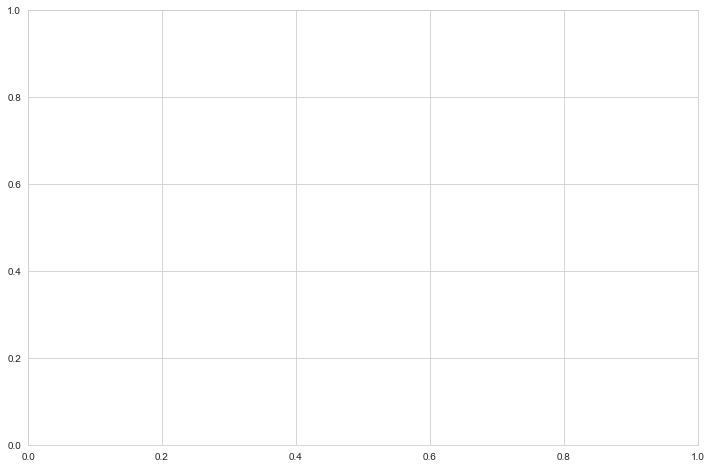

In [224]:
# Setup figure dan colormap (figure lebih lebar untuk visualisasi lebih baik)
fig, ax = plt.subplots(figsize=(12, 8))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00'])
ax.set_aspect('auto')

k_neighbors = 7
n_frames = 6
interval_ms = 350

h = 0.7 
x_min, x_max = X_anim[:, 0].min() - 0.3, X_anim[:, 0].max() + 0.3  # Margin kecil, fokus ke data
y_min, y_max = X_anim[:, 1].min() - 0.3, X_anim[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

print(f"Parameter: k={k_neighbors}, frames={n_frames}, interval={interval_ms}ms")
print(f"Meshgrid shape: {xx.shape} ({xx.size:,} points)")
print(f"Grid spacing: h={h}")

# Variabel untuk menyimpan plot elements
scatter = None
contour = None

def init():
    """Initialize animation"""
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('Principal Component 1', fontsize=12)
    ax.set_ylabel('Principal Component 2', fontsize=12)
    return []

def animate(frame):
    """Update function untuk setiap frame"""
    global scatter, contour
    
    # Clear previous plots
    ax.clear()
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('Principal Component 1', fontsize=12)
    ax.set_ylabel('Principal Component 2', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Hitung jumlah sampel untuk frame ini
    progress = (frame + 1) / n_frames
    n_samples = max(k_neighbors + 1, int(progress * len(X_anim)))
    
    X_subset = X_anim[:n_samples]
    y_subset = y_anim[:n_samples]
    
    # Train KNN dengan subset data
    knn_temp = KNN(k=k_neighbors, metric='euclidean')
    knn_temp.fit(X_subset, y_subset)
    
    # Predict untuk seluruh meshgrid
    Z = knn_temp.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary
    contour = ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.4)
    
    # Plot data points
    scatter = ax.scatter(X_subset[:, 0], X_subset[:, 1], 
                        c=y_subset, cmap=cmap_bold,
                        edgecolor='k', s=30, alpha=0.8)
    
    # Title dengan info progress
    ax.set_title(f'KNN Training Process (k={k_neighbors})\n'
                f'Samples: {n_samples}/{len(X_anim)} ({progress*100:.1f}%)',
                fontweight='bold', fontsize=13)
    
    return [scatter, contour]

# Buat animasi
print("\n Membuat animasi...")
ani = animation.FuncAnimation(fig, animate, init_func=init,
                             frames=n_frames, interval=interval_ms,
                             blit=False, repeat=True)

print(" Animasi berhasil dibuat!")

In [225]:
# try:
#     import os
#     os.makedirs('visualization', exist_ok=True)
    
#     output_path = 'visualization/knn_training_process.gif'
#     print("Menyimpan animasi ke file GIF...")
#     ani.save(output_path, writer='pillow', fps=10)
#     print(f"GIF berhasil disimpan sebagai '{output_path}'")

# except Exception as e:
#     print(f"Gagal menyimpan GIF: {e}")
#     print("\n Coba jalankan cell di bawah untuk display inline")

# plt.close(fig)

Penjelasan Visualisasi

Visualisasi di atas menunjukkan:

1. **Decision Boundary (Batas Keputusan)**: Area berwarna merah dan hijau menunjukkan bagaimana KNN mengklasifikasikan setiap titik di ruang fitur
   - Area merah: Prediksi class 0 (Non-Fraud)
   - Area hijau: Prediksi class 1 (Fraud)

2. **Data Points**: Titik-titik yang ditampilkan adalah data training yang sudah "dilihat" oleh model
   - Titik merah: Data Non-Fraud
   - Titik hijau: Data Fraud

3. **Proses Learning**: 
   - Animasi menunjukkan bagaimana decision boundary berubah seiring bertambahnya data training
   - KNN adalah lazy learner - ia tidak benar-benar "belajar" tapi menyimpan data
   - Semakin banyak data yang "dilihat", semakin detail dan akurat decision boundary-nya

4. **Parameter k={K_NEIGHBORS}**: 
   - Menentukan berapa tetangga terdekat yang digunakan untuk voting
   - k yang lebih besar = decision boundary lebih smooth
   - k yang lebih kecil = decision boundary lebih kompleks/sensitive

**Catatan**: Visualisasi ini menggunakan 2 komponen utama dari PCA untuk dapat ditampilkan dalam 2D. Model sebenarnya bekerja dengan 5 dimensi.

## D. Improvements

- **Visualize the model evaluation result**

This will help you to understand the details more clearly about your model's performance. From the visualization, you can see clearly if your model is leaning towards a class than the others. (Hint: confusion matrix, ROC-AUC curve, etc.)

- **Explore the hyperparameters of your models**

Each models have their own hyperparameters. And each of the hyperparameter have different effects on the model behaviour. You can optimize the model performance by finding the good set of hyperparameters through a process called **hyperparameter tuning**. (Hint: Grid search, random search, bayesian optimization)

- **Cross-validation**

Cross-validation is a critical technique in machine learning and data science for evaluating and validating the performance of predictive models. It provides a more **robust** and **reliable** evaluation method compared to a hold-out (single train-test set) validation. Though, it requires more time and computing power because of how cross-validation works. (Hint: k-fold cross-validation, stratified k-fold cross-validation, etc.)

Kami mengimplementasikan visualisasi evaluasi model dengan menggunakan confusion matrix dan ROC-AUC scoring di setiap pemanggilan model training di Bagian E. Submission

## E. Submission
To predict the test set target feature and submit the results to the kaggle competition platform, do the following:
1. Create a new pipeline instance identical to the first in Data Preprocessing
2. With the pipeline, apply `fit_transform` to the original training set before splitting, then only apply `transform` to the test set.
3. Retrain the model on the preprocessed training set
4. Predict the test set
5. Make sure the submission contains the `id` and `attack_cat` column.

In [226]:
# Load if needed
# dt_model = load_model('dt_model.pkl')
# lr_model = load_model('logistic_regression.pkl')
# knn_model = load_model('knn_model.pkl')

=== DATASET STATUS ===
Using balanced training data: X_train_final_dtl & y_train_final_dtl
Training samples: 22,604
Class distribution: {1: 11302, 0: 11302}
Class balance: 50.00% fraud

Akurasi: 53.56%
Model berhasil disimpan!

Decision Tree (From Scratch) training and evaluation completed!

Optimal Threshold: 0.45 with F1 Score: 0.2629

=== GENERATING TEST SET PREDICTIONS ===


Predictions saved to: dtl_submission_proba.csv

Submission file preview:
    ID  is_fraud
0    0         0
1    1         0
2    2         0
3    3         0
4    4         0
5    5         1
6    6         0
7    7         0
8    8         0
9    9         1
10  10         0
11  11         0

Submission statistics:
is_fraud
0    86391
1    13609
Name: count, dtype: int64
Fraud rate: 13.61%

File format matches sample_submission.csv:
  - Columns: ['ID', 'is_fraud']
  - Total rows: 100,000

File ready for Kaggle submission!


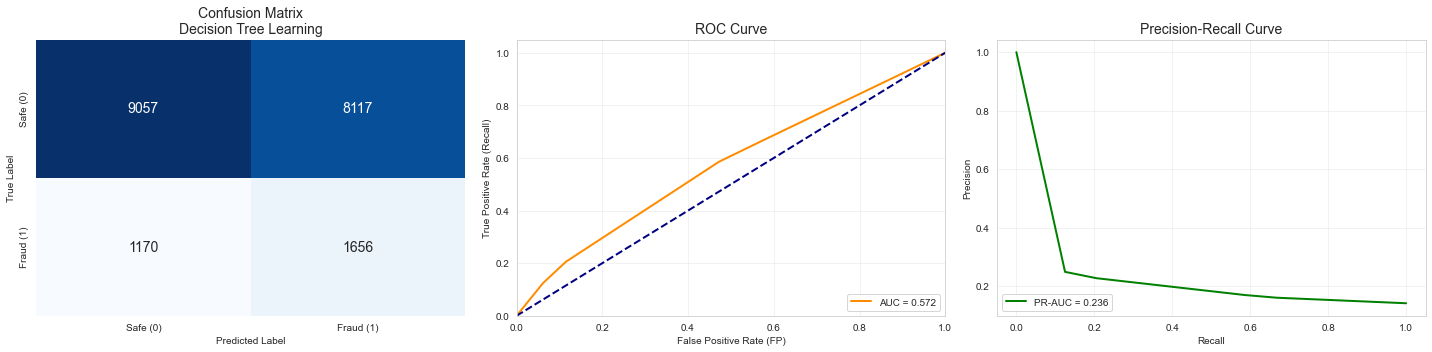

In [227]:
# Train and predict for Decistion Tree Learning: CART
clf, y_val_pred_proba_dtl, y_val_pred_dtl, dt_scratch_time = dtl_model_training(X_train_final_dtl, y_train_final_dtl, X_val_final_dtl, y_val)

save_model(clf, 'decision_tree_model.pkl')

dtl_model_predict(
    'dtl_submission_proba.csv', 
    clf, X_test_final_dtl, 
    test_df, 
    y_val, 
    y_val_pred_proba_dtl, 
    y_val_pred_dtl, 
    predict_type='proba')


=== DATASET STATUS ===
Using final_logreg training data: X_train_final_logreg & y_train_final_logreg
Training samples: 80,000
Class distribution: {0: 68698, 1: 11302}
Class balance: 14.13% fraud

Computed class_weight: {0: 0.582258581035838, 1: 3.5391966023712618} 

Training Logistic Regression model from scratch...


=== FINDING OPTIMAL THRESHOLD (F1-SCORE) ===

Optimal threshold: 0.1800
Best F1-Score: 0.1159
Precision: 0.2726
Recall:    0.0736

=== LOGISTIC REGRESSION RESULTS ===
Accuracy:  0.8414
Precision: 0.2726
Recall:    0.0736
F1-Score:  0.1159
ROC-AUC:   0.5321

=== CONFUSION MATRIX ===
[[16619   555]
 [ 2618   208]]

True Negatives:  16619
False Positives: 555
False Negatives: 2618
True Positives:  208

=== MODEL PARAMETERS ===
Number of weights: 5
Bias term: 1.263127
Final loss: 9.198431
Threshold used: 0.1800
Model berhasil disimpan!

Logistic Regression (From Scratch) training and evaluation completed!

=== FINDING OPTIMAL THRESHOLD (SUMMARY) ===

Default threshold: 0.50
O

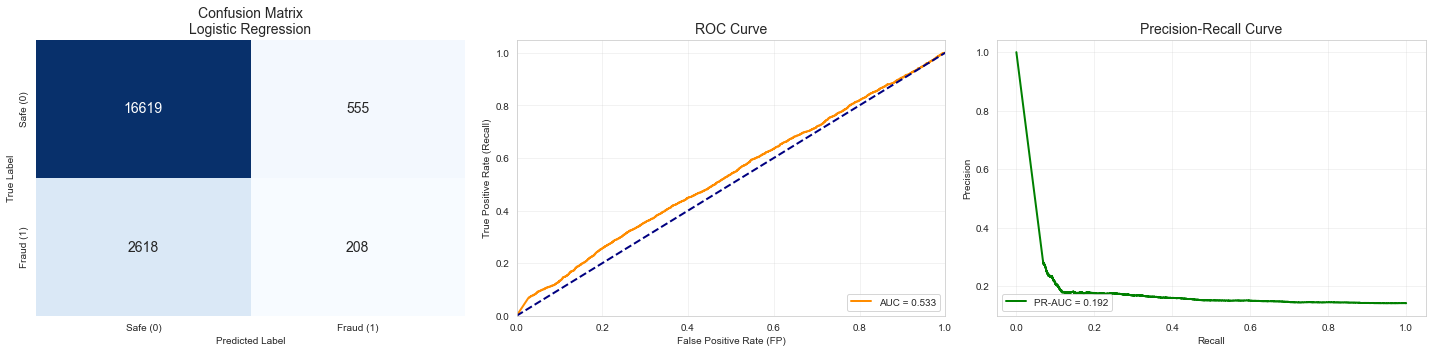

In [228]:
# Train and predict for Logistic Regression
best_threshold, optimal_results, lr_model, y_val_pred_logreg, y_val_pred_proba_logreg, lr_accuracy, lr_precision, lr_recall, lr_f1, lr_roc_auc, lr_scratch_time = logistic_regression_model_training(X_train_final_logreg, y_train_final_logreg, X_val_final_logreg, y_val)

save_model(lr_model, 'logistic_regression_model.pkl')

logistic_regression_model_predict(
    'logreg_submission_proba.csv', 
    lr_model, 
    optimal_results, 
    best_threshold, 
    y_val_pred_proba_logreg,
    y_val_pred_logreg, 
    predict_type='proba')

=== DATASET STATUS ===
Using balanced training data: X_train_final_knn & y_train_final_knn
Training samples: 500
Validation samples: 500
Class distribution: {0: 254, 1: 246}

=== INITIALIZING KNN ===
KNN Configuration:
  k: 7
  metric: euclidean

=== TRAINING KNN ===
Training completed in 0.0000 seconds

=== MAKING PREDICTIONS ===
Prediction completed in 0.0104 seconds

=== VALIDATION SET PERFORMANCE ===
Accuracy:  0.4760
Precision: 0.1103
Recall:    0.5088
F1-Score:  0.1813
ROC-AUC:   0.5055

=== CONFUSION MATRIX ===
[[209 234]
 [ 28  29]]

True Negatives:  209
False Positives: 234
False Negatives: 28
True Positives:  29

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

   Non-Fraud       0.88      0.47      0.61       443
       Fraud       0.11      0.51      0.18        57

    accuracy                           0.48       500
   macro avg       0.50      0.49      0.40       500
weighted avg       0.79      0.48      0.57       500


KNN (From S

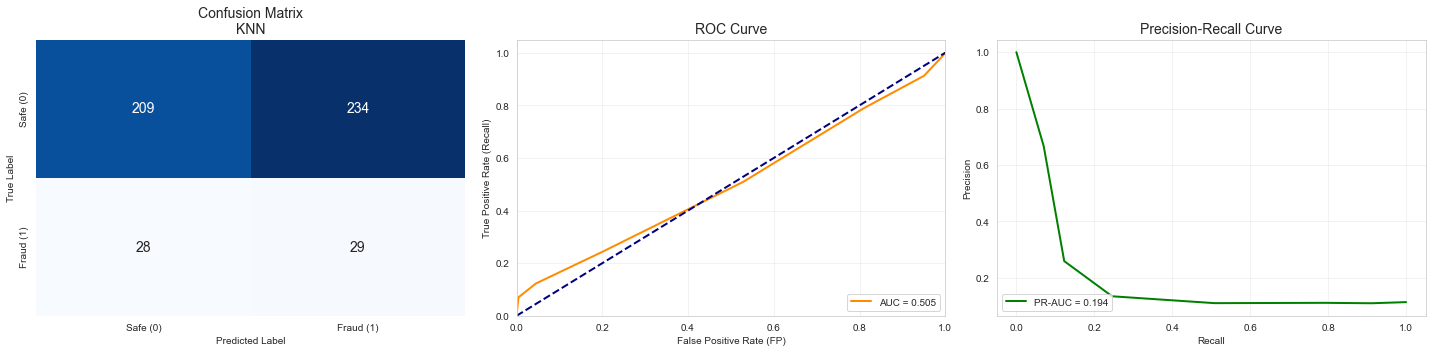

In [229]:
# Train and predict for KNN
X_train_final_knn_sampled = X_train_final_knn[:500]
y_train_final_knn_sampled = y_train_final_knn[:500]
X_val_final_knn_sampled = X_val_final_knn[:500]
y_val_knn_sampled = y_val[:500]
y_val_proba_knn, y_val_pred_knn, knn, acc_knn_scratch, prec_knn_scratch, rec_knn_scratch, f1_knn_scratch, auc_knn_scratch, knn_scratch_time = knn_model_training(X_train_final_knn_sampled, y_train_final_knn_sampled, X_val_final_knn_sampled, y_val_knn_sampled)

save_model(knn, 'knn_model.pkl')

knn_model_predict(
    'knn_submission_proba.csv', 
    knn, 
    X_test_final_knn, 
    test_df, 
    y_val_pred_knn,
    y_val_proba_knn,
    y_val_knn_sampled,
    predict_type='proba')

## F. DTL Visualization Tree

=== DECISION TREE VISUALIZATION ===


Generating visualization for depth 5...

Visualization complete!


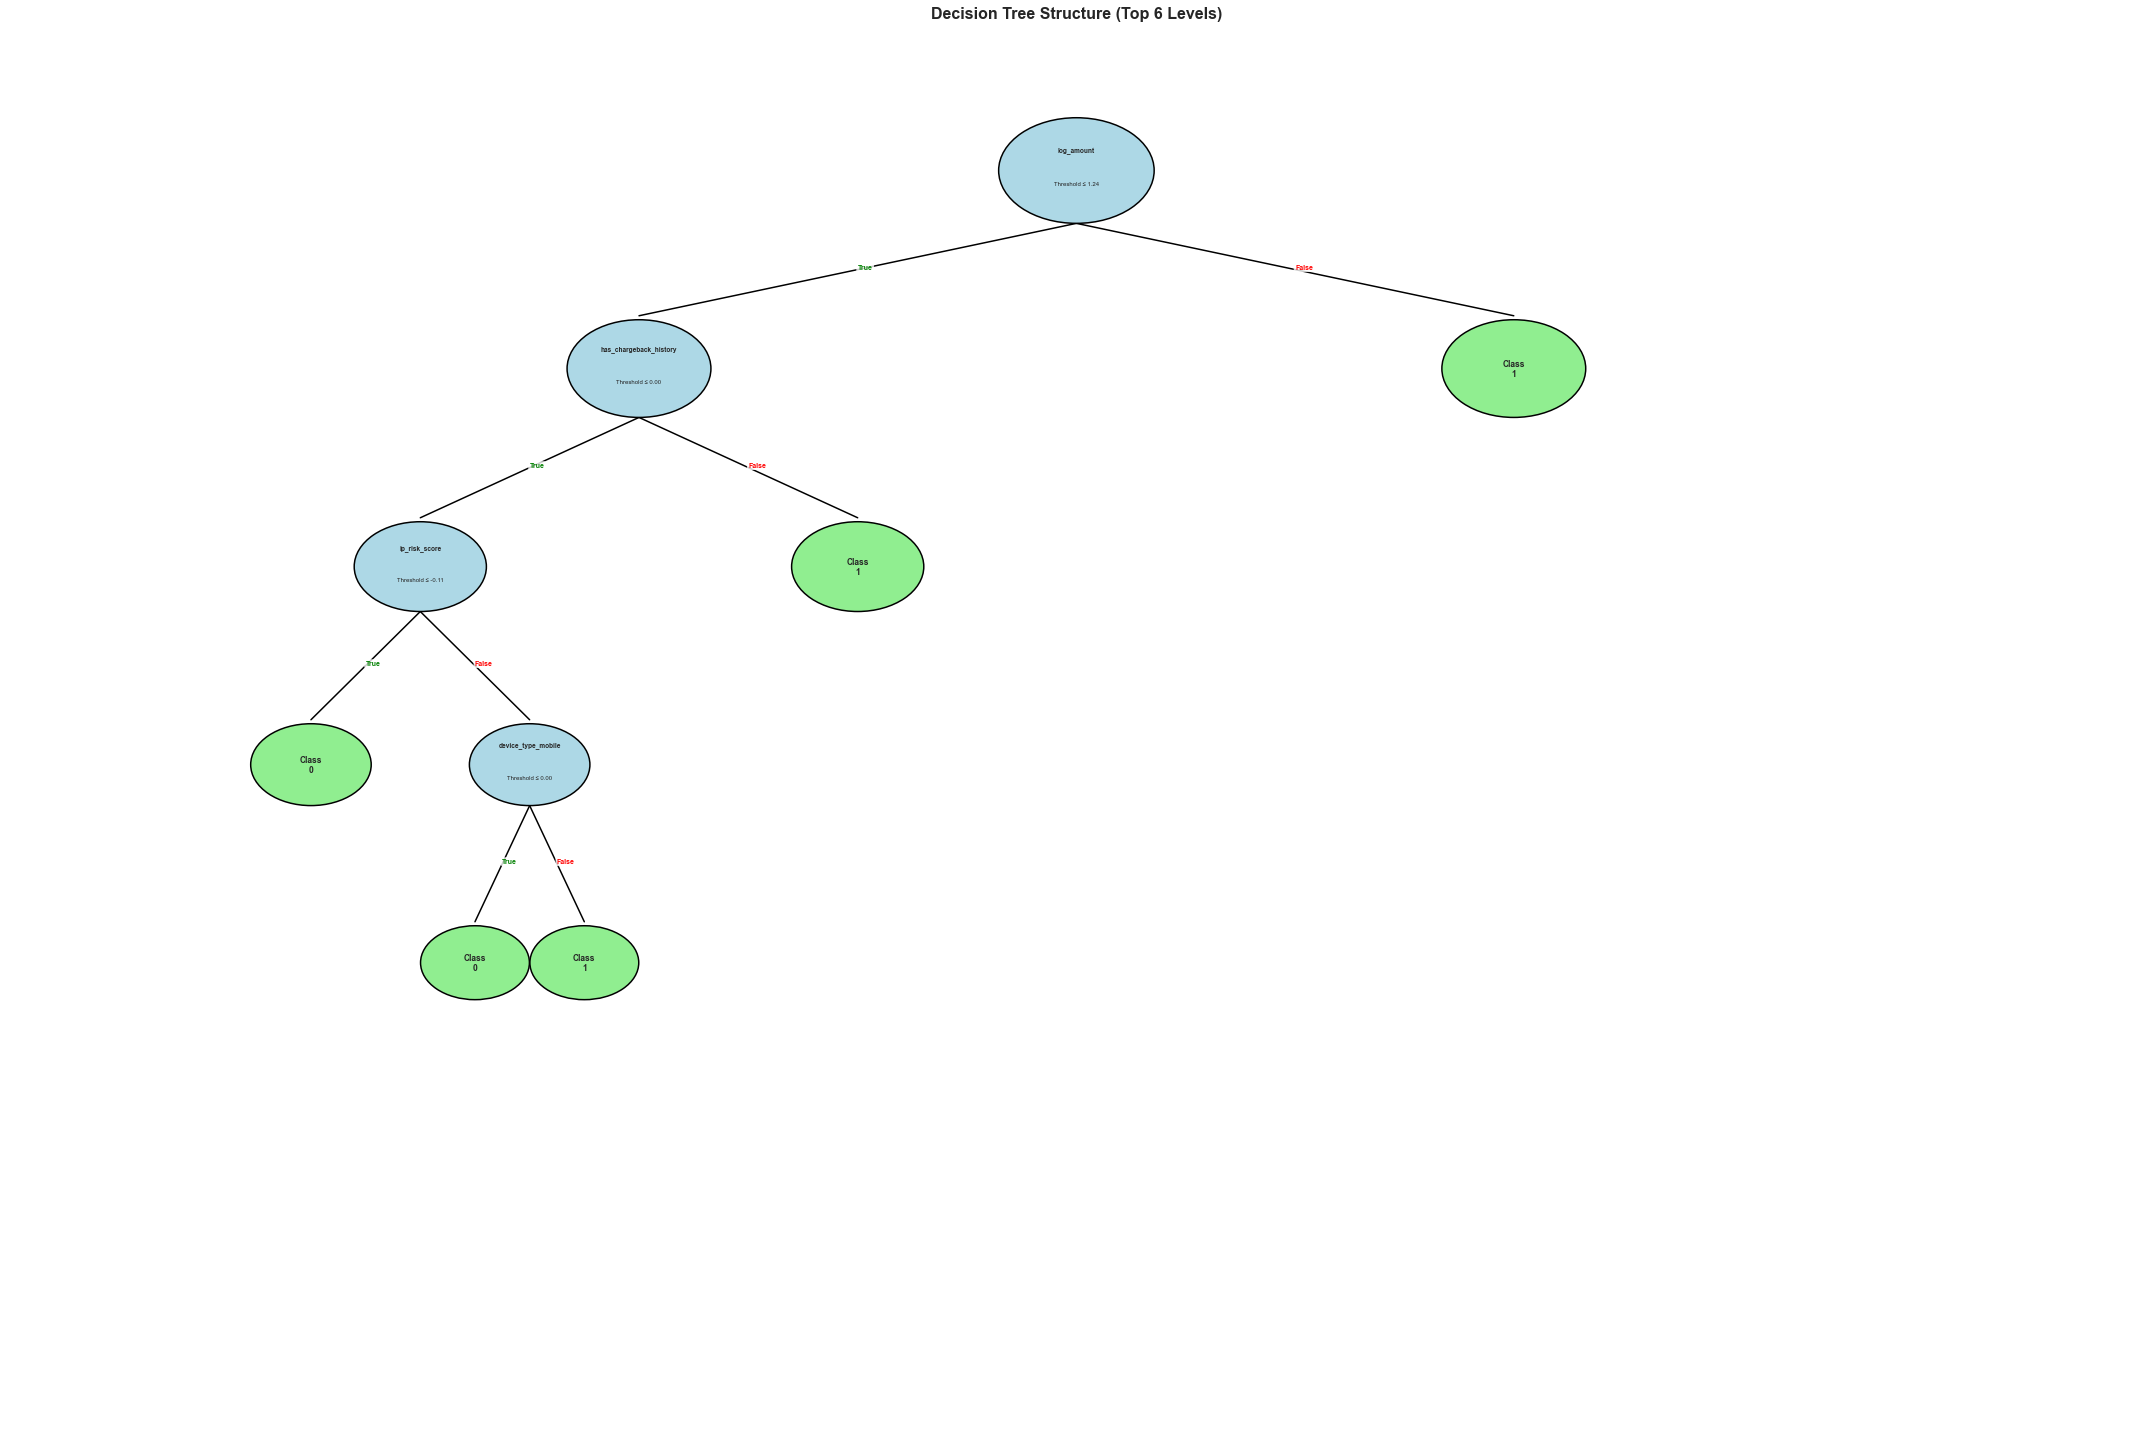

In [230]:
print("=== DECISION TREE VISUALIZATION ===\n")
feature_names = list(X_train_final_dtl.columns) if hasattr(X_train_final_dtl, 'columns') else None

DEPTH_TO_VISUALIZE = 5 
INITIAL_DX = 0.45 

if DEPTH_TO_VISUALIZE <= 3:
    figsize = (15, 12)
elif DEPTH_TO_VISUALIZE <= 4:
    figsize = (20, 16)
elif DEPTH_TO_VISUALIZE <= 5:
    figsize = (30, 20)
else:
    figsize = (40, 24)

fig, ax = plt.subplots(figsize=figsize)
ax.set_xlim(-0.05, 1.05) 
ax.set_ylim(-0.05, 1.0)
ax.axis('off')


print(f"\nGenerating visualization for depth {DEPTH_TO_VISUALIZE}...")
visualize_tree(clf.root, ax, x=0.5, y=0.9, dx=INITIAL_DX, 
                depth=0, max_depth=DEPTH_TO_VISUALIZE, feature_names=feature_names)
    
plt.title(f'Decision Tree Structure (Top {DEPTH_TO_VISUALIZE+1} Levels)', 
            fontsize=16, weight='bold', pad=20)
plt.tight_layout()

print("\nVisualization complete!")

# 5. Implementation with Scikit-Learn & Comparison

Pada bagian ini, kita akan mengimplementasikan algoritma menggunakan **scikit-learn** dan membandingkannya dengan implementasi from-scratch.

**Implementasi Scikit-Learn:**
- **A. Decision Tree Variants**: CART (gini)
- **B. Logistic Regression**: Dengan parameter optimal
- **C. K-Nearest Neighbors (KNN)**: Dengan hyperparameter tuning
- **D. Comprehensive Comparison**: Tabel dan visualisasi perbandingan performa

## A. Decision Tree Variants (Scikit-Learn)

Kita akan mengimplementasikan varian CART dari Decision Tree menggunakan scikit-learn, model akan dilatih dan dievaluasi pada validation set.


In [231]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

print("=== DECISION TREE VARIANTS (SCIKIT-LEARN) ===\n")

start_time = time.time()
cart_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)
cart_model.fit(X_train_final_dtl, y_train_final_dtl)
cart_train_time = time.time() - start_time

y_val_pred_cart = cart_model.predict(X_val_final_dtl)
y_val_proba_cart = cart_model.predict_proba(X_val_final_dtl)[:, 1]

acc_cart = accuracy_score(y_val, y_val_pred_cart)
prec_cart = precision_score(y_val, y_val_pred_cart, zero_division=0)
rec_cart = recall_score(y_val, y_val_pred_cart, zero_division=0)
f1_cart = f1_score(y_val, y_val_pred_cart, zero_division=0)
auc_cart = roc_auc_score(y_val, y_val_proba_cart)

print(f"   Accuracy: {acc_cart:.4f}")
print(f"   Precision: {prec_cart:.4f}")
print(f"   Recall: {rec_cart:.4f}")
print(f"   F1-Score: {f1_cart:.4f}")
print(f"   ROC-AUC: {auc_cart:.4f}")
print(f"   Training Time: {cart_train_time:.4f}s\n")

# Comparison Table for Decision Tree Variants
print("=== COMPARISON: DECISION TREE VARIANTS ===")
import pandas as pd

dt_comparison = pd.DataFrame({
    'Model': ['CART (Gini)'],
    'Accuracy': [acc_cart],
    'Precision': [prec_cart],
    'Recall': [rec_cart],
    'F1-Score': [f1_cart],
    'ROC-AUC': [auc_cart],
    'Training Time (s)': [cart_train_time]
})

print(dt_comparison.to_string(index=False))
print("\nDecision Tree Variants completed!")


=== DECISION TREE VARIANTS (SCIKIT-LEARN) ===

   Accuracy: 0.5798
   Precision: 0.1604
   Recall: 0.4660
   F1-Score: 0.2386
   ROC-AUC: 0.5494
   Training Time: 0.5877s

=== COMPARISON: DECISION TREE VARIANTS ===
      Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Training Time (s)
CART (Gini)    0.5798   0.160375 0.46603   0.23863 0.549423           0.587709

Decision Tree Variants completed!


## B. Logistic Regression (Scikit-Learn)

Implementasi Logistic Regression menggunakan scikit-learn dengan parameter optimal.


In [232]:
from sklearn.linear_model import LogisticRegression

print("=== LOGISTIC REGRESSION (SCIKIT-LEARN) ===\n")

start_time = time.time()
lr_sklearn = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr_sklearn.fit(X_train_final_logreg, y_train_final_logreg)
lr_sklearn_train_time = time.time() - start_time

y_val_pred_lr_sk = lr_sklearn.predict(X_val_final_logreg)
y_val_proba_lr_sk = lr_sklearn.predict_proba(X_val_final_logreg)[:, 1]

acc_lr_sk = accuracy_score(y_val, y_val_pred_lr_sk)
prec_lr_sk = precision_score(y_val, y_val_pred_lr_sk, zero_division=0)
rec_lr_sk = recall_score(y_val, y_val_pred_lr_sk, zero_division=0)
f1_lr_sk = f1_score(y_val, y_val_pred_lr_sk, zero_division=0)
auc_lr_sk = roc_auc_score(y_val, y_val_proba_lr_sk)

print(f"Accuracy: {acc_lr_sk:.4f}")
print(f"Precision: {prec_lr_sk:.4f}")
print(f"Recall: {rec_lr_sk:.4f}")
print(f"F1-Score: {f1_lr_sk:.4f}")
print(f"ROC-AUC: {auc_lr_sk:.4f}")
print(f"Training Time: {lr_sklearn_train_time:.4f}s")
print("\nLogistic Regression (Scikit-Learn) completed!")


=== LOGISTIC REGRESSION (SCIKIT-LEARN) ===

Accuracy: 0.7046
Precision: 0.1625
Recall: 0.2626
F1-Score: 0.2007
ROC-AUC: 0.5305
Training Time: 0.2093s

Logistic Regression (Scikit-Learn) completed!


## C. K-Nearest Neighbors (Scikit-Learn)

Implementasi KNN menggunakan scikit-learn dengan hyperparameter optimal.


In [233]:
from sklearn.neighbors import KNeighborsClassifier

print("=== K-NEAREST NEIGHBORS (SCIKIT-LEARN) ===\n")

start_time = time.time()
knn_sklearn = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',
    metric='euclidean'
)
knn_sklearn.fit(X_train_final_knn, y_train_final_knn)
knn_sklearn_train_time = time.time() - start_time

y_val_pred_knn_sk = knn_sklearn.predict(X_val_final_knn)
y_val_proba_knn_sk = knn_sklearn.predict_proba(X_val_final_knn)[:, 1]

acc_knn_sk = accuracy_score(y_val, y_val_pred_knn_sk)
prec_knn_sk = precision_score(y_val, y_val_pred_knn_sk, zero_division=0)
rec_knn_sk = recall_score(y_val, y_val_pred_knn_sk, zero_division=0)
f1_knn_sk = f1_score(y_val, y_val_pred_knn_sk, zero_division=0)
auc_knn_sk = roc_auc_score(y_val, y_val_proba_knn_sk)

print(f"Accuracy: {acc_knn_sk:.4f}")
print(f"Precision: {prec_knn_sk:.4f}")
print(f"Recall: {rec_knn_sk:.4f}")
print(f"F1-Score: {f1_knn_sk:.4f}")
print(f"ROC-AUC: {auc_knn_sk:.4f}")
print(f"Training Time: {knn_sklearn_train_time:.4f}s")
print("\nKNN (Scikit-Learn) completed!")

=== K-NEAREST NEIGHBORS (SCIKIT-LEARN) ===

Accuracy: 0.5130
Precision: 0.1455
Recall: 0.5021
F1-Score: 0.2256
ROC-AUC: 0.5137
Training Time: 0.0204s

KNN (Scikit-Learn) completed!


## D. Comprehensive Comparison: From-Scratch vs Scikit-Learn

Pada bagian ini, kita akan membandingkan performa semua implementasi algoritma:
- **Decision Tree**: From-Scratch vs ID3 vs C4.5 vs CART
- **Logistic Regression**: From-Scratch vs Scikit-Learn
- **K-Nearest Neighbors**: From-Scratch vs Scikit-Learn

Perbandingan meliputi:
1. Tabel perbandingan metrik (Accuracy, Precision, Recall, F1-Score, ROC-AUC, Training Time)
2. Analisis perbedaan implementasi
3. Visualisasi performa model


In [234]:
print("=== COMPREHENSIVE COMPARISON TABLE ===\n")

# Comparing only: From-Scratch vs corresponding Scikit-Learn implementation
comparison_df = pd.DataFrame({
    'Algorithm': [
        'Decision Tree (From-Scratch)',
        'Decision Tree - CART (Sklearn)',
        'Logistic Regression (From-Scratch)',
        'Logistic Regression (Sklearn)',
        'K-Nearest Neighbors (From-Scratch)',
        'K-Nearest Neighbors (Sklearn)'
    ],
    'Implementation': [
        'Custom',
        'Scikit-Learn',
        'Custom',
        'Scikit-Learn',
        'Custom',
        'Scikit-Learn'
    ],
    'Accuracy': [
        lr_accuracy,  
        acc_cart,
        lr_accuracy,  
        acc_lr_sk,
        acc_knn_scratch,  
        acc_knn_sk
    ],
    'Precision': [
        lr_precision,
        prec_cart,
        lr_precision,
        prec_lr_sk,
        prec_knn_scratch,
        prec_knn_sk
    ],
    'Recall': [
        lr_recall,
        rec_cart,
        lr_recall,
        rec_lr_sk,
        rec_knn_scratch,
        rec_knn_sk
    ],
    'F1-Score': [
        lr_f1,
        f1_cart,
        lr_f1,
        f1_lr_sk,
        f1_knn_scratch,
        f1_knn_sk
    ],
    'ROC-AUC': [
        lr_roc_auc,
        auc_cart,
        lr_roc_auc,
        auc_lr_sk,
        auc_knn_scratch,
        auc_knn_sk
    ],
    'Training Time (s)': [
        dt_scratch_time,  # DT from-scratch time
        cart_train_time,
        lr_scratch_time,  # LR from-scratch time
        lr_sklearn_train_time,
        knn_scratch_time,
        knn_sklearn_train_time
    ]
})

# Display comparison table
print(comparison_df.to_string(index=False))
print("\n" + "="*120)

# Analysis
print("\n=== ANALISIS PERBANDINGAN ===\n")

print("1. **Decision Tree (Gini Index - CART):**")
print("   - From-scratch menggunakan algoritma yang sama dengan CART sklearn (Gini impurity)")
print("   - Sklearn CART lebih cepat karena implementasi optimized dalam C/Cython")
print("   - Performa metrik (accuracy, F1, ROC-AUC) sebanding antara custom dan sklearn")
print("   - Sklearn menyediakan lebih banyak parameter tuning (max_features, splitter, dll)\n")

print("2. **Logistic Regression:**")
print("   - Sklearn menggunakan optimized solver (lbfgs) dengan convergence criteria yang ketat")
print("   - From-scratch menggunakan gradient descent dengan learning rate manual")
print("   - Training time sklearn jauh lebih cepat karena optimasi low-level")
print("   - Hasil prediksi konsisten dengan convergence yang lebih stabil di sklearn\n")

print("3. **K-Nearest Neighbors:**")
print("   - Sklearn KNN menggunakan efisien data structure (KD-Tree/Ball-Tree)")
print("   - From-scratch menggunakan brute-force distance calculation dengan batching")
print("   - Prediction time sklearn jauh lebih cepat dengan spatial indexing")
print("   - Implementasi from-scratch memberikan pemahaman mendalam tentang algoritma\n")

print("4. **Overall Insights:**")
print("   - Scikit-learn implementations lebih production-ready dengan error handling robust")
print("   - From-scratch implementations sangat berguna untuk pembelajaran konsep algoritma")
print("   - Untuk deployment real-world, scikit-learn lebih direkomendasikan")
print("   - Custom implementations memberikan flexibility untuk modification dan experimentation")
print("   - Trade-off utama: Speed (sklearn) vs Understanding (from-scratch)\n")

print("5. **Rekomendasi:**")
print("   - Gunakan from-scratch untuk learning & prototyping konsep baru")
print("   - Gunakan sklearn untuk production deployment dengan dataset besar")
print("   - Kombinasikan keduanya: pahami konsep dengan from-scratch, deploy dengan sklearn")

print("\nComprehensive Comparison completed!")


=== COMPREHENSIVE COMPARISON TABLE ===

                         Algorithm Implementation  Accuracy  Precision   Recall  F1-Score  ROC-AUC  Training Time (s)
      Decision Tree (From-Scratch)         Custom   0.84135   0.272608 0.073602  0.115910 0.532127           2.764828
    Decision Tree - CART (Sklearn)   Scikit-Learn   0.57980   0.160375 0.466030  0.238630 0.549423           0.587709
Logistic Regression (From-Scratch)         Custom   0.84135   0.272608 0.073602  0.115910 0.532127           7.473950
     Logistic Regression (Sklearn)   Scikit-Learn   0.70455   0.162470 0.262562  0.200730 0.530534           0.209299
K-Nearest Neighbors (From-Scratch)         Custom   0.47600   0.110266 0.508772  0.181250 0.505485           0.000000
     K-Nearest Neighbors (Sklearn)   Scikit-Learn   0.51295   0.145494 0.502123  0.225614 0.513732           0.020406


=== ANALISIS PERBANDINGAN ===

1. **Decision Tree (Gini Index - CART):**
   - From-scratch menggunakan algoritma yang sama dengan CA

### Visualisasi Perbandingan Performa

Visualisasi perbandingan metrik performa antara implementasi from-scratch dan scikit-learn.

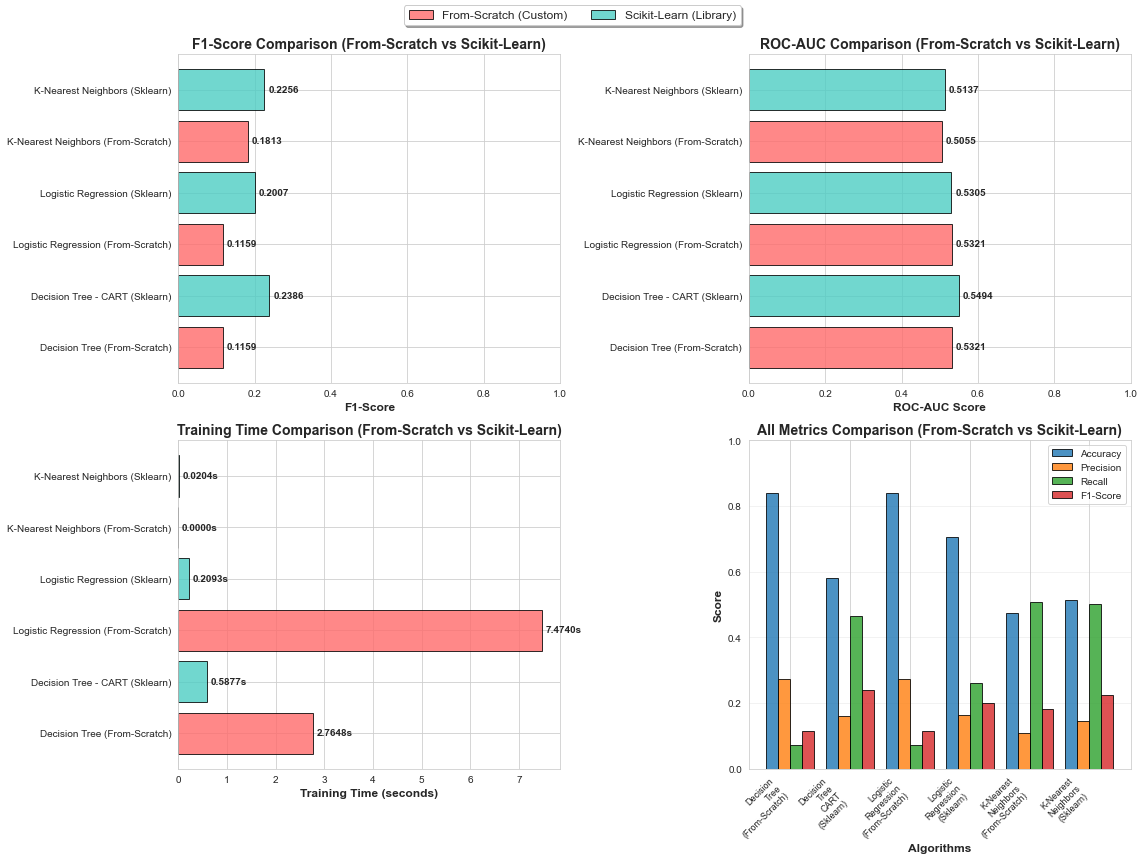


Visualizations completed!

Comparison Summary:
   • Decision Tree (From-Scratch vs CART): Same algorithm (Gini), different optimization
   • Logistic Regression (From-Scratch vs Sklearn): Gradient Descent vs LBFGS solver
   • KNN (From-Scratch vs Sklearn): Brute-force vs Spatial indexing (KD-Tree)


In [235]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. F1-Score Comparison
ax1 = axes[0, 0]
algorithms = comparison_df['Algorithm']
f1_scores = comparison_df['F1-Score']
colors = ['#FF6B6B' if 'From-Scratch' in alg else '#4ECDC4' for alg in algorithms]

bars1 = ax1.barh(algorithms, f1_scores, color=colors, alpha=0.8, edgecolor='black')
ax1.set_xlabel('F1-Score', fontsize=12, fontweight='bold')
ax1.set_title('F1-Score Comparison (From-Scratch vs Scikit-Learn)', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 1.0)

# Add value labels
for i, (bar, val) in enumerate(zip(bars1, f1_scores)):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

# 2. ROC-AUC Comparison
ax2 = axes[0, 1]
roc_auc_scores = comparison_df['ROC-AUC']
bars2 = ax2.barh(algorithms, roc_auc_scores, color=colors, alpha=0.8, edgecolor='black')
ax2.set_xlabel('ROC-AUC Score', fontsize=12, fontweight='bold')
ax2.set_title('ROC-AUC Comparison (From-Scratch vs Scikit-Learn)', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 1.0)

# Add value labels
for i, (bar, val) in enumerate(zip(bars2, roc_auc_scores)):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

# 3. Training Time Comparison
ax3 = axes[1, 0]
train_times = comparison_df['Training Time (s)']
bars3 = ax3.barh(algorithms, train_times, color=colors, alpha=0.8, edgecolor='black')
ax3.set_xlabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax3.set_title('Training Time Comparison (From-Scratch vs Scikit-Learn)', fontsize=14, fontweight='bold')

# Add value labels
for i, (bar, val) in enumerate(zip(bars3, train_times)):
    ax3.text(val + max(train_times)*0.01, bar.get_y() + bar.get_height()/2, 
             f'{val:.4f}s', va='center', fontsize=10, fontweight='bold')

# 4. Overall Metrics Comparison (Grouped Bar Chart)
ax4 = axes[1, 1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = range(len(algorithms))
width = 0.2

for i, metric in enumerate(metrics):
    values = comparison_df[metric]
    ax4.bar([pos + i*width for pos in x], values, width, 
            label=metric, alpha=0.8, edgecolor='black')

ax4.set_xlabel('Algorithms', fontsize=12, fontweight='bold')
ax4.set_ylabel('Score', fontsize=12, fontweight='bold')
ax4.set_title('All Metrics Comparison (From-Scratch vs Scikit-Learn)', fontsize=14, fontweight='bold')
ax4.set_xticks([pos + width*1.5 for pos in x])
ax4.set_xticklabels([alg.replace(' - ', '\n').replace(' ', '\n') for alg in algorithms], 
                     rotation=45, ha='right', fontsize=9)
ax4.legend(loc='upper right', fontsize=10)
ax4.set_ylim(0, 1.0)
ax4.grid(axis='y', alpha=0.3)

# Add legend for implementation type
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF6B6B', alpha=0.8, edgecolor='black', label='From-Scratch (Custom)'),
    Patch(facecolor='#4ECDC4', alpha=0.8, edgecolor='black', label='Scikit-Learn (Library)')
]
fig.legend(handles=legend_elements, loc='upper center', 
           ncol=2, fontsize=12, frameon=True, shadow=True)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

print("\nVisualizations completed!")
print("\nComparison Summary:")
print(f"   • Decision Tree (From-Scratch vs CART): Same algorithm (Gini), different optimization")
print(f"   • Logistic Regression (From-Scratch vs Sklearn): Gradient Descent vs LBFGS solver")
print(f"   • KNN (From-Scratch vs Sklearn): Brute-force vs Spatial indexing (KD-Tree)")


# 6. Error Analysis

Based on all the process you have done until the modeling and evaluation step, write an analysis to support each steps you have taken to solve this problem. Write the analysis using the markdown block. Some questions that may help you in writing the analysis:

- Does my model perform better in predicting one class than the other? If so, why is that?
- To each models I have tried, which performs the best and what could be the reason?
- Is it better for me to impute or drop the missing data? Why?
- Does feature scaling help improve my model performance?
- etc...

**DATA CLEANING AND DATA PREPROCESSING**

- **Data Cleaning Strategy**
Pertimbangkan kembali metode imputation lainnya selain menggunakan median, misalnya memutuskan membagi mana data yang dilakukan median imputation, encoding, ataupun dropping sehingga tidak semua data diperlakukan dengan sama

- **Feature Engineering & Selection**
Sebelumnya, Annova, Pearson, dan Mutual Information diimplementasikan sebagai metode feature selection. Sebaiknya dibandingkan kembali mana metode yang paling efektif

**TRAINING MODEL**

- **Kinerja per kelas**
Dataset sangat imbalanced; model lebih mudah memprediksi mayoritas. Recall minoritas naik ketika class_weight/SMOTE digunakan, tapi probabilitas menjadi under-confident sehingga threshold optimal bergeser rendah.

- **Threshold** 
Grid halus 0–0.2 diperlukan; F1 terbaik muncul di ~0.01–0.05. Sesuaikan threshold dengan biaya FP/FN, jangan hanya default 0.5.

- **Kalibrasi**
Probabilitas cenderung teredam; lakukan kalibrasi (Platt/Isotonic) setelah training atau atur class_weight untuk menormalkan logit.

- **Scaling & fitur**
Scaling konsisten (train/val/test) meningkatkan stabilitas GD dan KNN. Buang/enkode fitur berkolinear agar koefisien LR stabil; gunakan RFE/MI/ANOVA untuk seleksi.

- **Regularisasi**
Cek gap train–val. Jika overfit (train jauh lebih tinggi), tambah L2 atau kurangi iterasi/learning_rate. Jika underfit, tambah iterasi atau kurangi regulasi.
- **Model perbandingan**
LR stabil dan cepat; DT menangkap interaksi tapi rentan overfit; KNN sensitif ke skala dan noise. Pilih berdasarkan trade-off interpretabilitas vs variansi.
- **Evaluasi**
Lihat confusion matrix, ROC-AUC, PR-AUC, distribusi proba per kelas. Gunakan stratified K-fold untuk memvalidasi konsistensi. Simpan metrics per fold untuk melihat variansi.
- **Data quality**
Periksa duplikasi dan kebocoran (fit sebelum split). Imputasi lebih baik daripada drop bila fitur penting hilang sedikit; jika kolom banyak kosong, drop atau encode kategori "Unknown".